# Assignment 2: Evaluating Clustering with Elbow and Silhouette Methods

In this task, you will evaluate the performance of clustering algorithms (K-Means or GMM) using the Elbow method and Silhouette analysis. You will also investigate the impact of clustering on four relevant metrics.

## Datasets
* **FIFA 23 Players Dataset**: This dataset contains detailed attributes of professional soccer players. The objective is to cluster players based on their skills and playing styles. Relevant features for clustering include:
  * Age
  * Overall rating (general skill level)
  * Potential (maximum projected skill level)
  * Value (market price in €)
  * Wage (weekly salary)
  * Shooting, Passing, Dribbling (technical abilities)
  * Defending, Physicality (defensive capabilities)

  You can download the dataset from Kaggle [FIFA 23 Dataset - Kaggle](https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database?select=FIFA23_official_data.csv)

* **EastWestAirlines Dataset**: This dataset contains information about airline customers and their behaviors. You should preprocess the dataset as necessary before applying the clustering algorithm.

## Tasks

1. Implement the Elbow method and Silhouette analysis to determine the optimal number of clusters for both the FIFA 23 and EastWestAirlines datasets.
2. Apply both K-Means and GMM clustering algorithms to each dataset and compare their performance in determining the optimal number of clusters.
3. Evaluate the clustering quality using the following four metrics:
   * **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters. Learn more here: [Silhouette Score - scikit-learn documentation](https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient).
   * **Inertia**: Sum of squared distances of points to their closest cluster center. Explanation can be found here: [Inertia and Clustering Evaluation](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).
   * **Davies-Bouldin Index**: Measures the average similarity ratio of each cluster with its most similar cluster. Learn about it here: [Davies-Bouldin Index - scikit-learn documentation](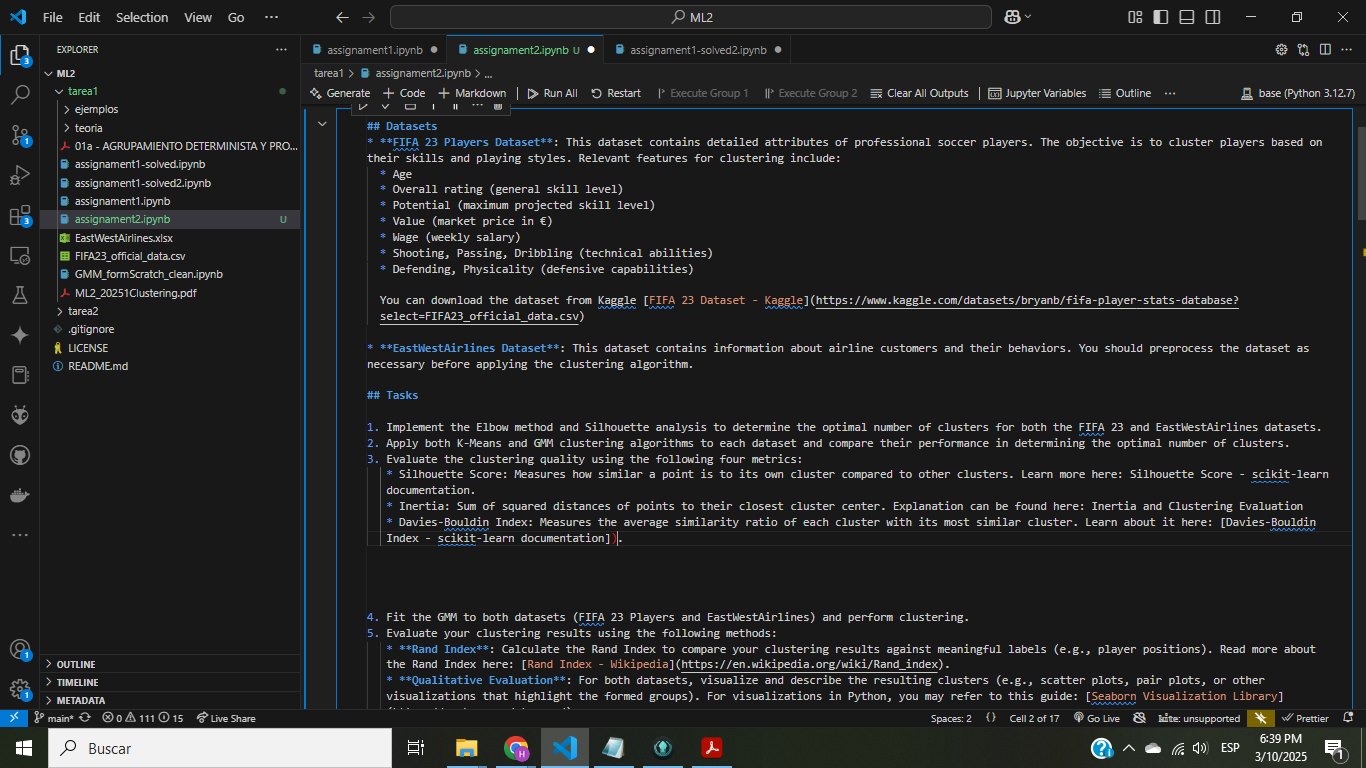).


## Solution

> **Note**: The solution will be described in spanish.

### 1. Librerias y configuraciones previas


In [121]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sns
import pandas as pd
from scipy.stats import multivariate_normal
from sklearn.metrics import rand_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

SEED = 42

### 2. Funciones

A continuación se ponen las funciones suministradas por el profesor

In [123]:
def scatter_plot(X, y=None):
  plt.style.use("fivethirtyeight")
  fig, ax = plt.subplots(figsize=(7, 4))

  if y is None:
    ax.scatter(X[:, 0], X[:, 1], marker=".", s=10)
  else:
    ax.scatter(X[:, 0], X[:, 1], marker=".", s=10, c=y)

  ax.set_xlabel("$x_1$", fontsize=14)
  ax.set_ylabel("$x_2$", fontsize=14)
  ax.tick_params(axis='both', labelsize=8)

  ax.grid(False)
  plt.tight_layout()

  plt.savefig("scatter.png", dpi=600, transparent=True)

  plt.show()

# Codigo adaptado (del suministrado por el profesor) por Skynet
def train_kmeans(X, max_k, seed):
    """
    Entrena modelos KMeans con diferentes valores de k y calcula métricas.

    Parámetros:
    - X: np.array o pd.DataFrame, datos de entrada para clustering.
    - max_k: int, número máximo de clústeres a evaluar (mínimo permitido es 2).
    - seed: int, semilla para asegurar reproducibilidad.

    Retorna:
    - kmeans_models: lista de modelos KMeans ajustados para cada k.
    - inertias: lista con las inercias (inertia_) para cada modelo.
    - silhouettes: lista con los puntajes de silhouette para cada modelo.
    - ks: array con los valores de k evaluados.
    """
    if max_k < 2:
        raise ValueError("El número máximo de clústeres (max_k) debe ser al menos 2.")

    ks = np.arange(2, max_k + 1)  # Genera valores de k desde 2 hasta max_k
    inertias = []
    silhouettes = []
    kmeans_models = []
    
    for k in ks:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init='auto')
        kmeans.fit(X)
        
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, kmeans.labels_))
        kmeans_models.append(kmeans)
    
    return kmeans_models, inertias, silhouettes, ks

# Codigo adaptado (a partir del anterior) por Skynet
def train_gmm(X, max_k, seed):
    """
    Entrena modelos Gaussian Mixture Model (GMM) con diferentes valores de k y calcula métricas.

    Parámetros:
    - X: np.array o pd.DataFrame, datos de entrada para clustering.
    - max_k: int, número máximo de componentes a evaluar (mínimo permitido es 2).
    - seed: int, semilla para asegurar reproducibilidad.

    Retorna:
    - gmm_models: lista de modelos GMM ajustados para cada k.
    - bics: lista con los valores BIC para cada modelo.
    - aics: lista con los valores AIC para cada modelo.
    - silhouettes: lista con los puntajes de silhouette para cada modelo.
    - ks: array con los valores de k evaluados.
    """
    if max_k < 2:
        raise ValueError("El número máximo de componentes (max_k) debe ser al menos 2.")

    ks = np.arange(2, max_k + 1)  # Valores de k desde 2 hasta max_k
    bics, aics, silhouettes = [], [], []
    gmm_models = []

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=seed)
        gmm.fit(X)
        
        y_pred = gmm.predict(X)  # Etiquetas de clúster
        
        # Calcular métricas
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))
        silhouettes.append(silhouette_score(X, y_pred))
        gmm_models.append(gmm)

    return gmm_models, bics, aics, silhouettes, ks

### 3. Dataset Fifa 23

#### 3.1. Carga de datos

In [40]:
# Se carga el dataset
csv_file = 'FIFA23_official_data.csv'
df_players = pd.read_csv(csv_file)
# Renombrado de las columnas
df_players.columns = df_players.columns.str.replace(' ', '_')
df_players.columns = df_players.columns.str.lower()
# Selección de las columnas a utilizar
features_selected = ['age', 'overall', 'potential', 'special', 'value', 'wage', 'height', 'weight']
df = df_players[features_selected]
df.head(3)

,age,overall,potential,special,value,wage,height,weight
0,27,87,88,2312,€91M,€115K,189cm,82kg
1,27,86,87,2305,€78.5M,€190K,179cm,69kg
2,30,85,85,2303,€46.5M,€46K,172cm,69kg


Funciones para convertir datos tipo string a numeros:

In [41]:
def convert_mk_to_numeric(value):
    if isinstance(value, str):  # Asegurar que el valor es una cadena
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Si no es string, devolver el valor original

def convert_height_to_numeric(height):
    if isinstance(height, str):  # Asegurar que el valor es una cadena
        return float(height.replace('cm', ''))
    return height  # Si no es string, devolver el valor original

def convert_weight_to_numeric(weight):
    if isinstance(weight, str):  # Asegurar que el valor es una cadena
        return float(weight.replace('kg', ''))
    return weight  # Si no es string, devolver el valor original

Aplicando las funciones anteriores para convertir las columnas a numericas tenemos:

In [42]:
# Columna Value
df['value'] = df['value'].str[1:]
df['value']= df['value'].apply(convert_mk_to_numeric)

# Columna Wage
df['wage'] = df['wage'].str[1:]
df['wage'] = df['wage'].apply(convert_mk_to_numeric)

# Columna Height
df['height'] = df['height'].apply(convert_height_to_numeric)

# Columna Weight
df['weight'] = df['weight'].apply(convert_weight_to_numeric)

# Inspeccion del frame
df.head(3)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9624\2353514176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value'] = df['value'].str[1:]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9624\2353514176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value']= df['value'].apply(convert_mk_to_numeric)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9624\2353514176.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

,age,overall,potential,special,value,wage,height,weight
0,27,87,88,2312,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,78500000.0,190000.0,179.0,69.0
2,30,85,85,2303,46500000.0,46000.0,172.0,69.0


In [51]:
estadisticas = df.describe()
stadisticas_resumen = estadisticas.loc[['mean', 'std']]
stadisticas_resumen.T.round(2)

,mean,std
age,23.13,4.64
overall,63.37,8.04
potential,70.98,6.53
special,1537.92,285.89
value,2739788.39,7841275.70
wage,8189.81,20476.73
height,180.89,6.96
weight,74.33,6.98


#### 3.2. Metodo Kmeans

Al inicio se realizó un escalamiento pero los resultados no eran buenos de modo que se omitió este paso (tal y como se muestra en la parte comentada a continuación). Despues de esto los resultados mejoraron asi que se dejaron los datos sin escalar. 

In [91]:
X = df.values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X) 

In [93]:
# kmeans_k, inertias, silhouettes, ks = train_kmeans(X_scaled, max_k = 30, seed=SEED)
kmeans_k, inertias, silhouettes, ks = train_kmeans(X, max_k = 15, seed=SEED)

#### 3.3. Metricas

In [ ]:
#print(silhouettes)
#print(inertias)
df_summary = pd.DataFrame({'inertia': inertias, 'silhouette': silhouettes}, index=ks)
df_summary.index.name = 'k'
df_summary

,inertia,silhouette
k,,
2,3.828782e+17,0.923023
3,1.790280e+17,0.894019
4,1.098286e+17,0.861685
5,7.498715e+16,0.853125
6,5.386600e+16,0.806864
7,4.321218e+16,0.742960
8,3.354063e+16,0.767927
9,2.724639e+16,0.761569
10,2.029970e+16,0.697998


##### Metodo del codo

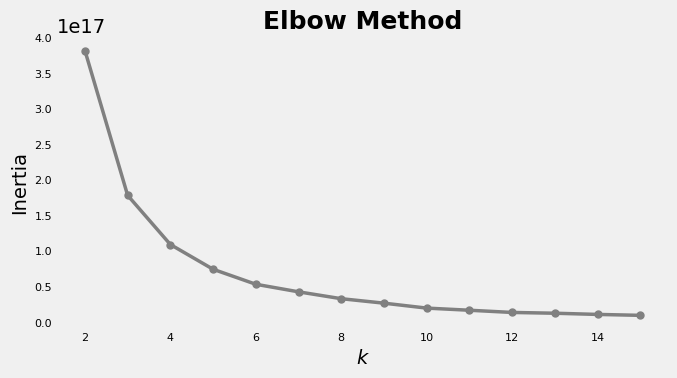

In [99]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks, inertias, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Inertia", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Elbow Method", fontsize=18, fontweight="bold")
ax.grid(False)

#ax.annotate("Elbow",
#            xy=(4, inertias[2]),
#            xytext=(0.55, 0.45),
#            textcoords="figure fraction",
#            fontsize=16,
#            arrowprops=dict(facecolor="black", shrink=0.1)
#            )

plt.tight_layout()
plt.savefig("elbow.png", dpi=600, transparent=True)
plt.show()

##### Análisis de silueta

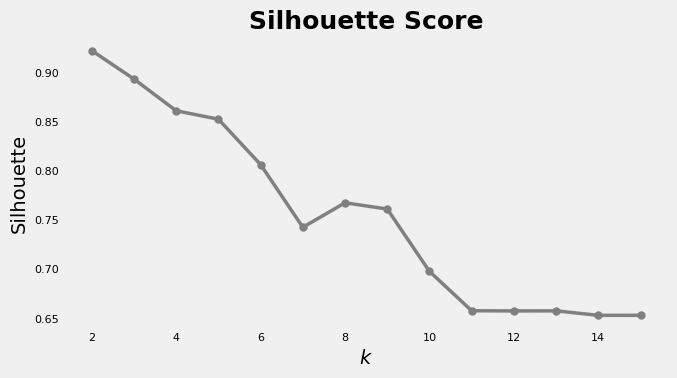

In [100]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks, silhouettes, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Silhouette", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Silhouette Score", fontsize=18, fontweight="bold")
ax.grid(False)

# ax.annotate("silhouette score = {:.2f}".format(silhouettes[3]),
#             xy=(5, silhouettes[3]),
#             xytext=(0.65, 0.8),
#             textcoords="figure fraction",
#             fontsize=12,
#             arrowprops=dict(facecolor="black", shrink=0.1)
#             )

plt.tight_layout()
plt.savefig("silhouette_score.png", dpi=600, transparent=True)
plt.show()

##### Análisis de siluetas para evaluar la calidad de la agrupación 

Para k=2 el promedio del silhouette es: 0.92


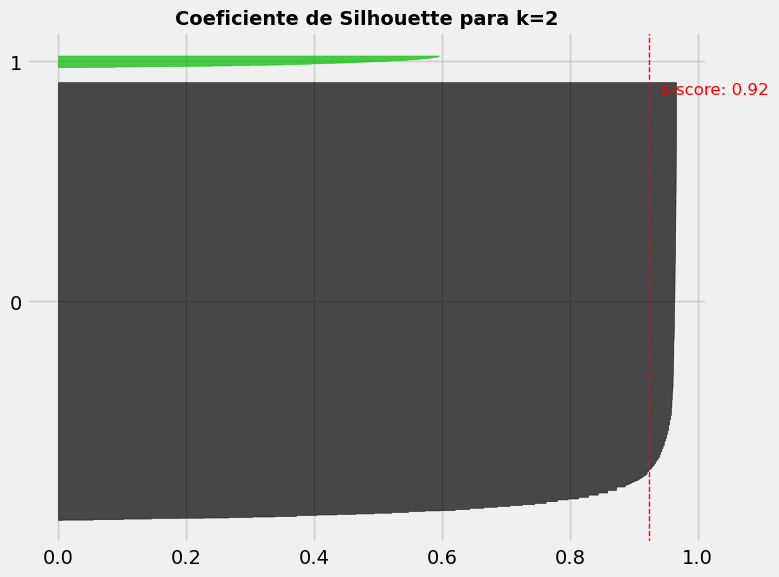

Para k=3 el promedio del silhouette es: 0.89


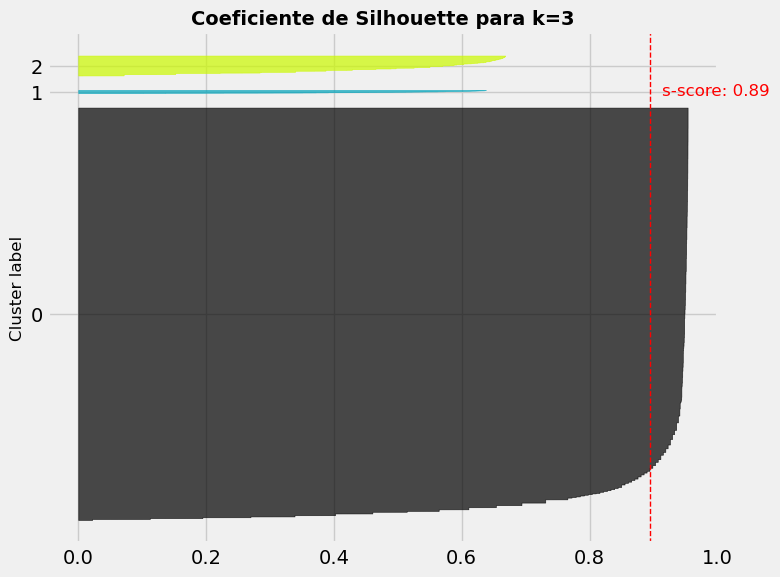

Para k=4 el promedio del silhouette es: 0.86


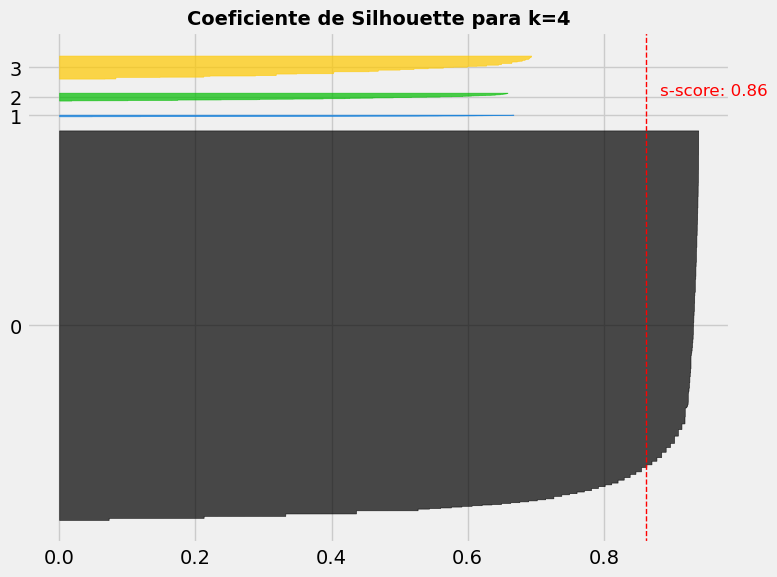

Para k=5 el promedio del silhouette es: 0.85


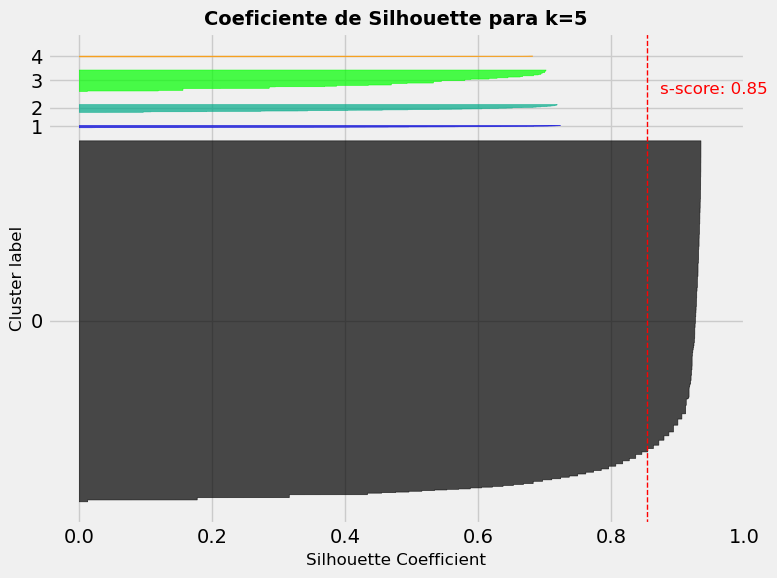

Para k=6 el promedio del silhouette es: 0.81


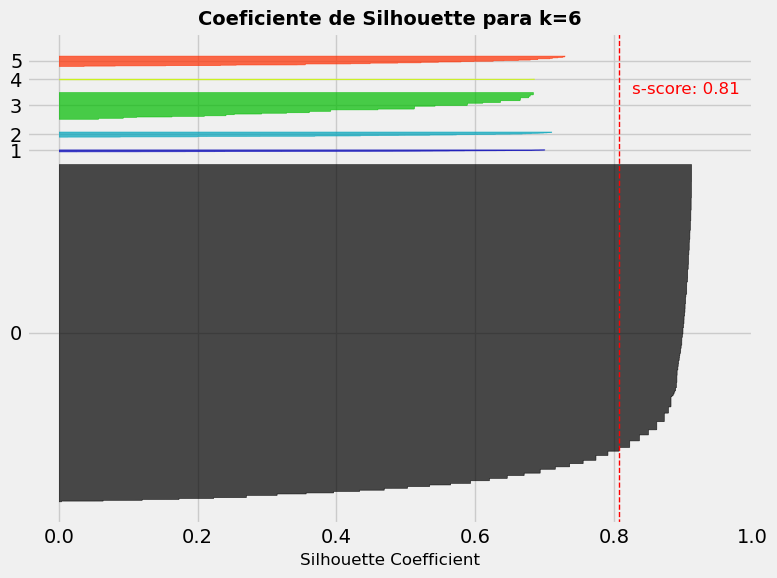

Para k=7 el promedio del silhouette es: 0.74


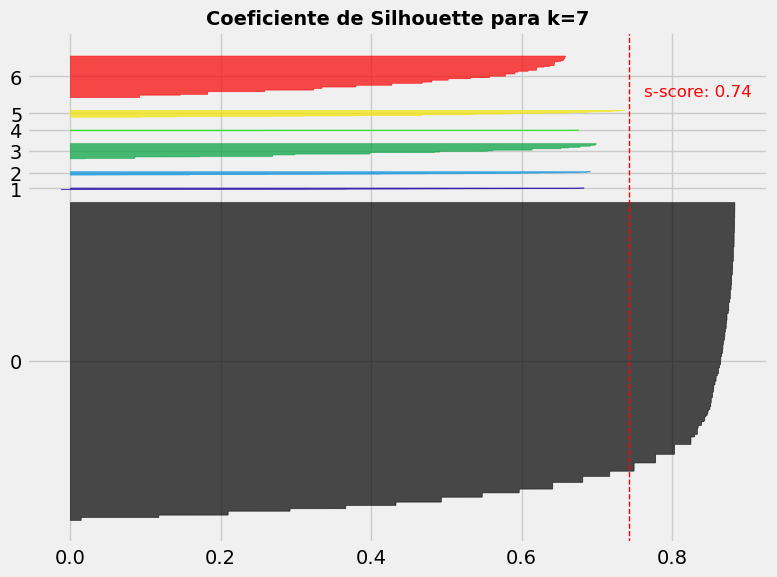

Para k=8 el promedio del silhouette es: 0.77


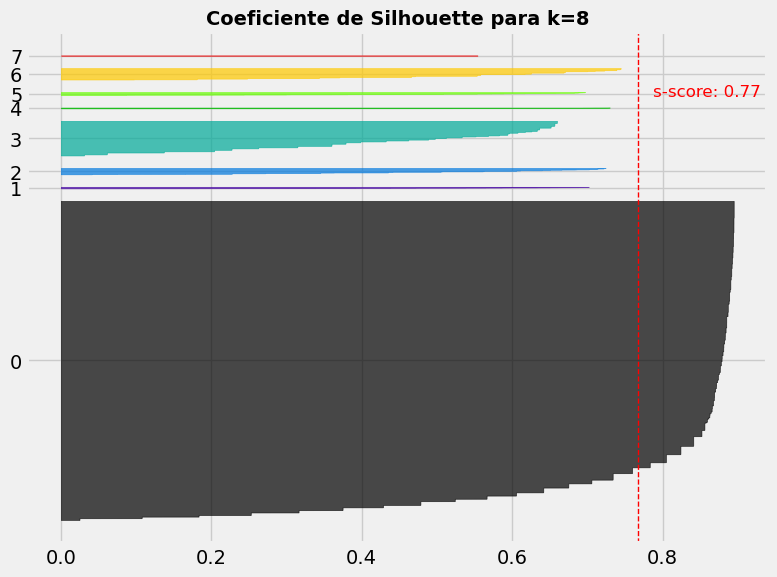

Para k=9 el promedio del silhouette es: 0.76


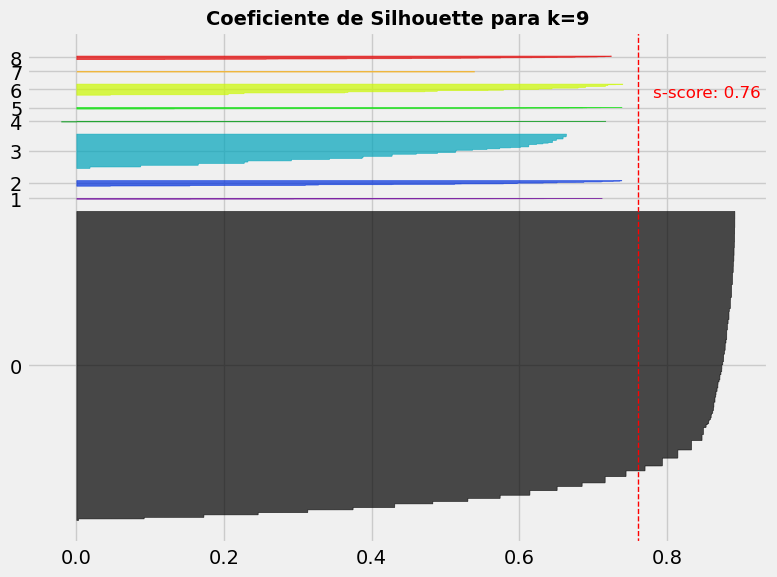

Para k=10 el promedio del silhouette es: 0.70


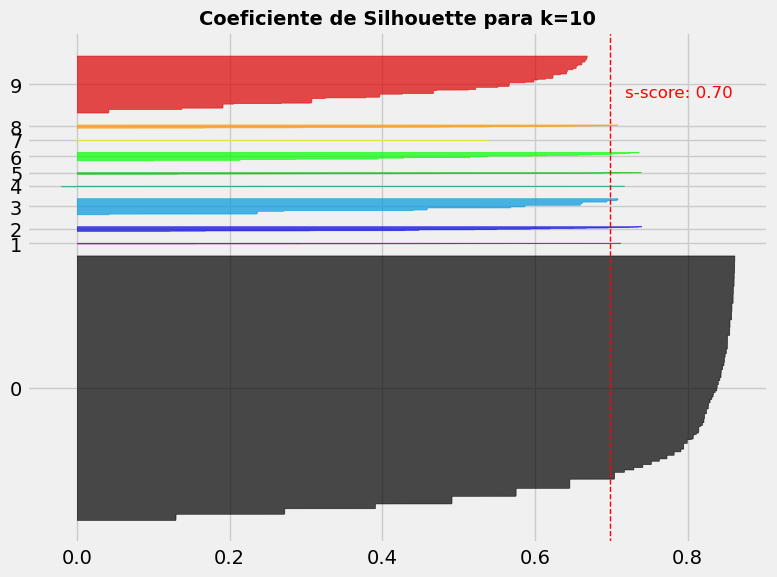

Para k=11 el promedio del silhouette es: 0.66


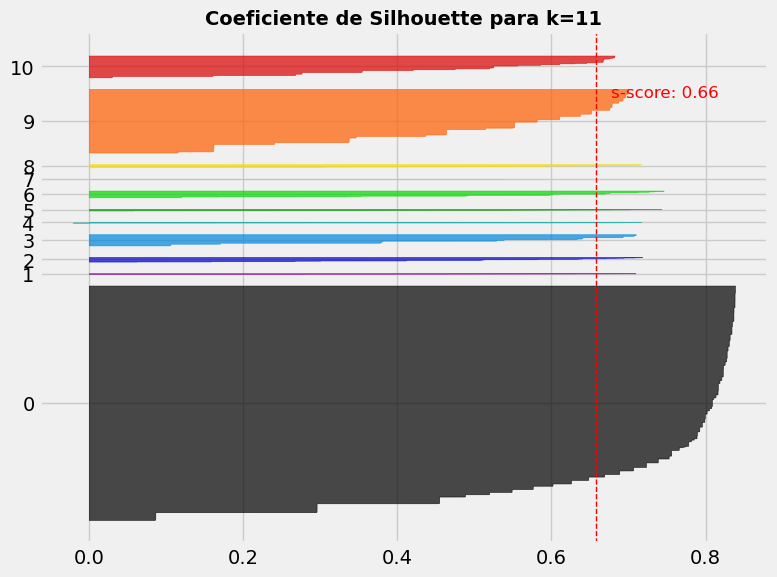

Para k=12 el promedio del silhouette es: 0.66


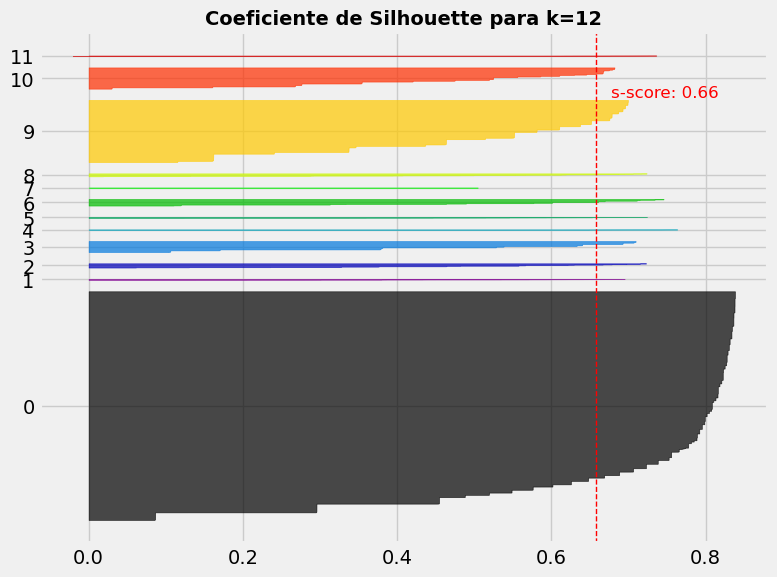

Para k=13 el promedio del silhouette es: 0.66


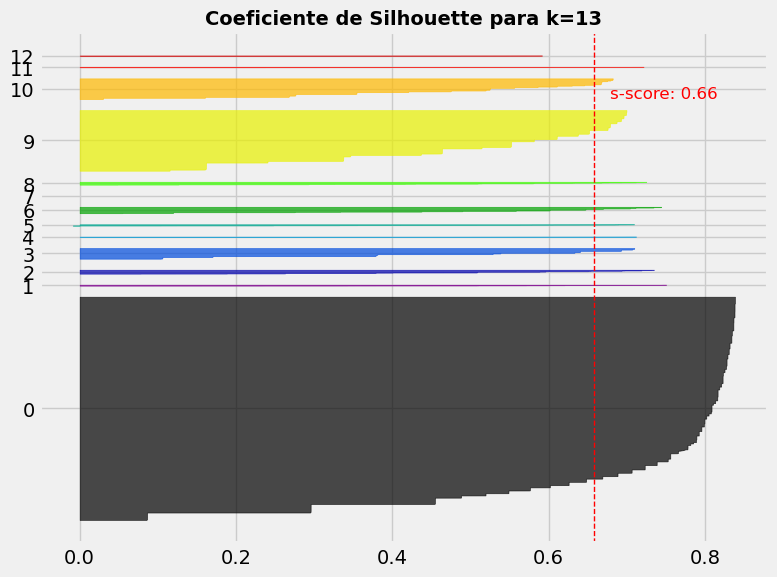

Para k=14 el promedio del silhouette es: 0.65


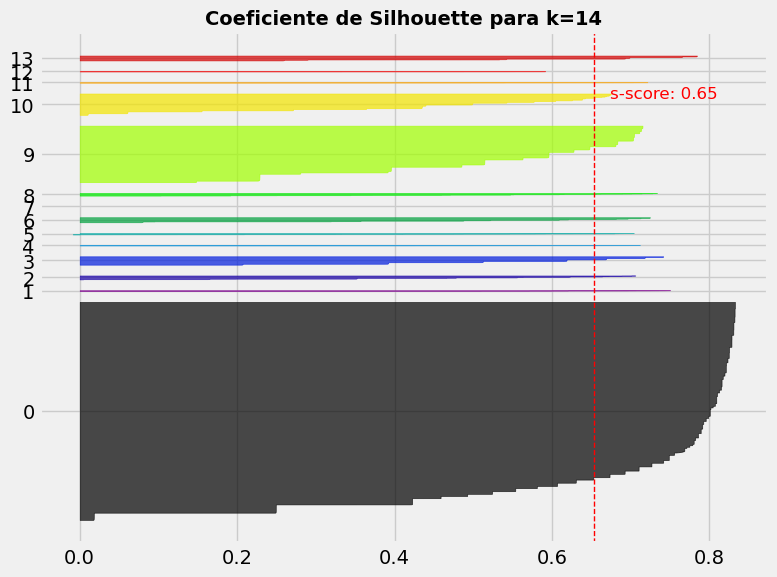

Para k=15 el promedio del silhouette es: 0.65


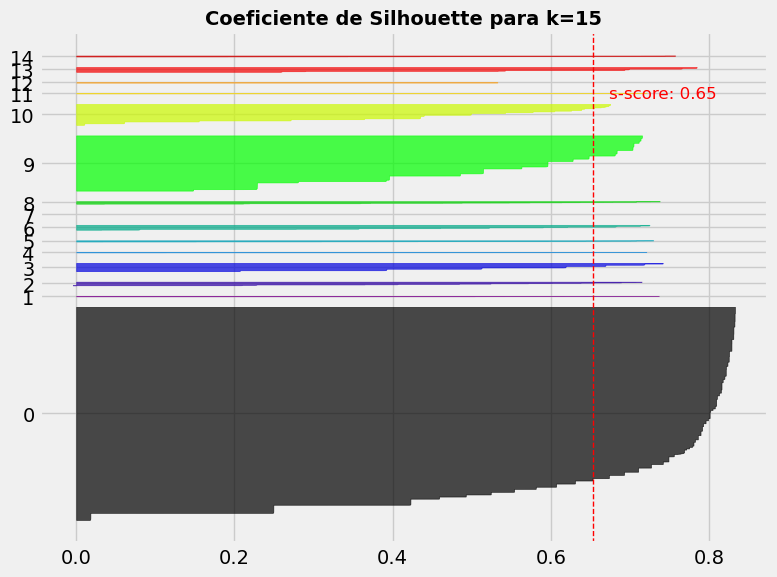

In [101]:
for k in ks:
    plt.figure(figsize=(8, 6))  # Ajusta el tamaño de la figura
    
    y_pred = kmeans_k[k - 2].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)
    silhouette_avg = silhouette_score(X, y_pred)  # Cálculo del promedio
    print(f"Para k={k} el promedio del silhouette es: {silhouette_avg:.2f}")

    padding = len(X) // 30
    pos = padding
    ticks = []
    
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.nipy_spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster label", fontsize=12)

    if k in (5, 6):
        plt.gca().set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient", fontsize=12)

    # Agregar línea vertical del silhouette_avg
    plt.axvline(silhouette_avg, color='red', linestyle="--", linewidth=1)
    
    # Agregar texto al lado de la línea
    plt.text(silhouette_avg + 0.02, pos * 0.9, f"s-score: {silhouette_avg:.2f}",
             color="red", fontsize=12, verticalalignment='center')

    plt.title(f"Coeficiente de Silhouette para k={k}", fontsize=14, fontweight="bold")

    plt.grid(True)
    plt.tight_layout()
    plt.show()  # Muestra cada gráfico individualmente


Parece que la mejor elección para el caso va a ser para k = 11.

**To Do**: Explicación.

In [104]:
kmeans_elegido = kmeans_k[9]
kmeans_elegido

KMeans(n_clusters=11, random_state=42)

A continuación se muestran los centroides resultantes:

In [117]:

for i in range(kmeans_elegido.n_clusters):
    print(f"Cluster {i}: \n\t {kmeans_elegido.cluster_centers_[i].round(3)}\n")
#    print(_)



Cluster 0: 
	 [2.227700e+01 5.921100e+01 6.802800e+01 1.427171e+03 4.848117e+05
 1.709306e+03 1.807920e+02 7.400800e+01]

Cluster 1: 
	 [2.560000e+01 8.547500e+01 8.857500e+01 2.043425e+03 6.948750e+07
 1.440250e+05 1.827250e+02 7.680000e+01]

Cluster 2: 
	 [2.62450000e+01 7.98840000e+01 8.25580000e+01 1.94532200e+03
 2.33025751e+07 5.11757510e+04 1.81747000e+02 7.58540000e+01]

Cluster 3: 
	 [2.61180000e+01 7.61010000e+01 7.96580000e+01 1.87654500e+03
 9.16137566e+06 3.17891530e+04 1.81104000e+02 7.54060000e+01]

Cluster 4: 
	 [2.65520000e+01 8.77930000e+01 9.02410000e+01 2.05555200e+03
 9.83103448e+07 1.92172414e+05 1.82069000e+02 7.72070000e+01]

Cluster 5: 
	 [2.58590000e+01 8.37050000e+01 8.65130000e+01 2.05051300e+03
 4.98141026e+07 1.04910256e+05 1.82090000e+02 7.65260000e+01]

Cluster 6: 
	 [2.66190000e+01 7.82140000e+01 8.08800000e+01 1.89657800e+03
 1.54281525e+07 4.33073310e+04 1.81927000e+02 7.58090000e+01]

Cluster 7: 
	 [2.2000e+01 8.9500e+01 9.4500e+01 2.1485e+03 1.6925e

In [ ]:
# Añadir los labels de los clusters al dataframe
df['cluster'] = kmeans_elegido.labels_

In [119]:
# Ver cantidad de datos por cluster
cluster_counts = df['cluster'].value_counts()
cluster_counts

cluster
0     11880
9      3225
10     1103
3       567
6       341
2       233
8       162
5        78
1        40
4        29
7         2
Name: count, dtype: int64

Vemos que aunque todos los clusters tienen elementos, hay unos con muy pocos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9624\41151461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans_elegido.labels_


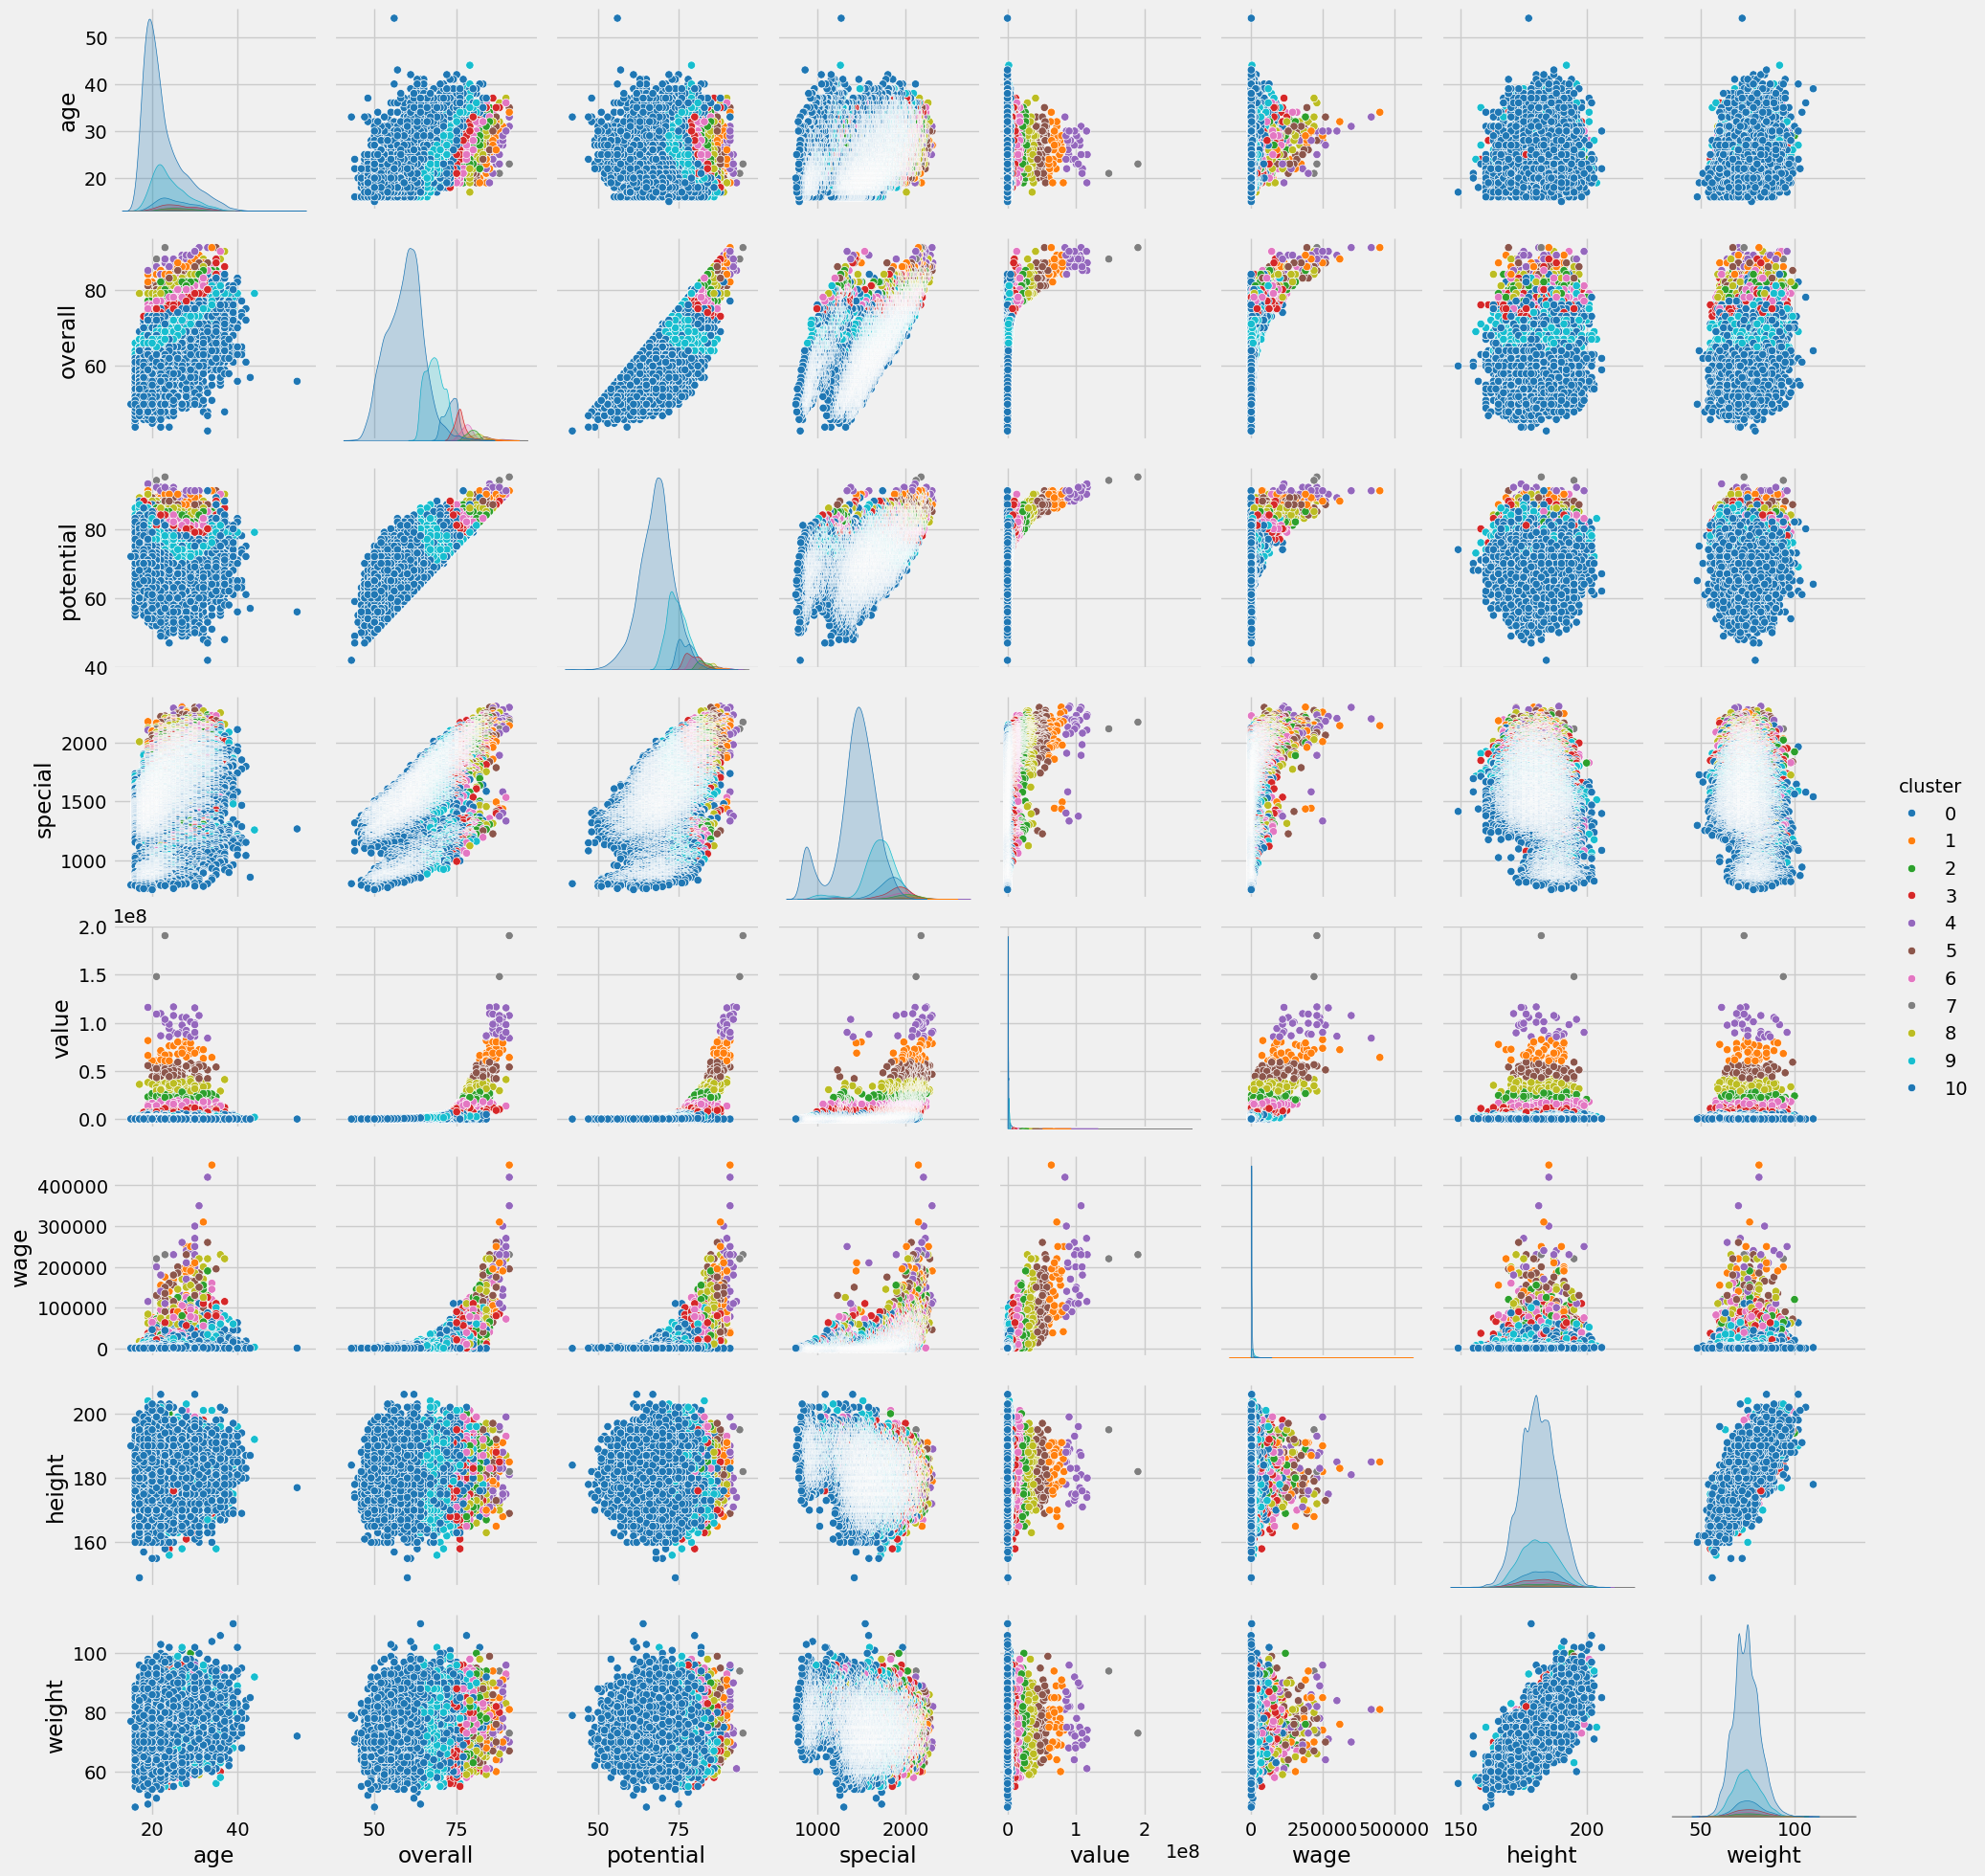

In [ ]:
# Crear el pairplot
sns.pairplot(df, hue='cluster', diag_kind='kde', palette='tab10')
plt.show()

#### 3.4. GMM

In [126]:
try:
    df.drop('cluster', axis=1, inplace=True)        
except:
    pass
df.head(3)

,age,overall,potential,special,value,wage,height,weight
0,27,87,88,2312,91000000.0,115000.0,189.0,82.0
1,27,86,87,2305,78500000.0,190000.0,179.0,69.0
2,30,85,85,2303,46500000.0,46000.0,172.0,69.0


No se escaló por que cuando esto se realizaba el resultado era peor.

In [133]:
X = df.values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X) 

In [134]:
# Entrenar modelos GMM
# gmm_models, bics, aics, silhouettes, ks = train_gmm(X_scaled, max_k=15, seed=SEED)
gmm_models, bics, aics, silhouettes, ks = train_gmm(X, max_k=15, seed=SEED)

In [135]:
df_gmm_summary = pd.DataFrame({'BIC': bics, 'AIC': aics, 'silhouette': silhouettes}, index=ks)
df_gmm_summary.index.name = 'k'
df_gmm_summary

,BIC,AIC,silhouette
k,,,
2,1.612403e+06,1.611710e+06,0.562736
3,1.581140e+06,1.580098e+06,0.376080
4,1.564166e+06,1.562774e+06,0.123069
5,1.557074e+06,1.555331e+06,0.130089
6,1.546117e+06,1.544024e+06,0.104883
7,1.510532e+06,1.508089e+06,-0.024827
8,1.511914e+06,1.509121e+06,0.041083
9,1.508905e+06,1.505762e+06,-0.027636
10,1.504918e+06,1.501426e+06,-0.062919


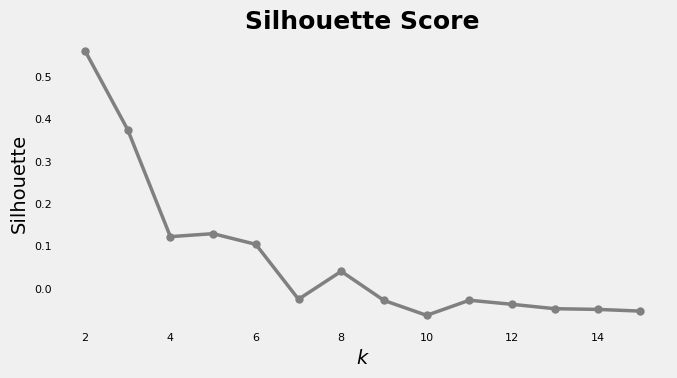

In [136]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks, silhouettes, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Silhouette", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Silhouette Score", fontsize=18, fontweight="bold")
ax.grid(False)

# ax.annotate("silhouette score = {:.2f}".format(silhouettes[3]),
#             xy=(5, silhouettes[3]),
#             xytext=(0.65, 0.8),
#             textcoords="figure fraction",
#             fontsize=12,
#             arrowprops=dict(facecolor="black", shrink=0.1)
#             )

plt.tight_layout()
plt.savefig("silhouette_score.png", dpi=600, transparent=True)
plt.show()

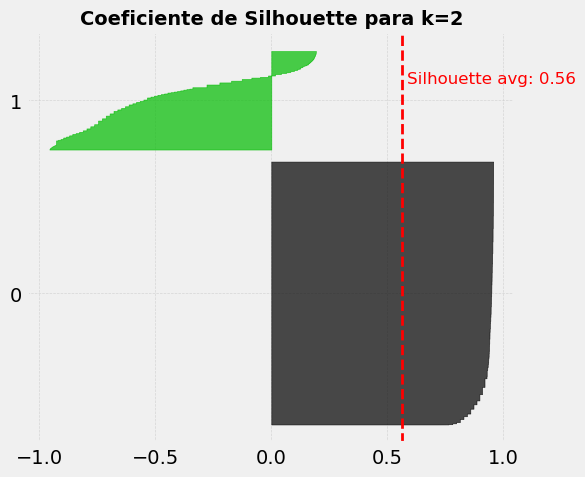

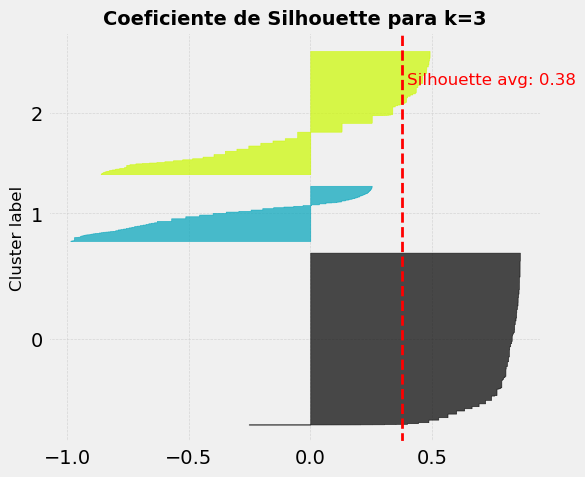

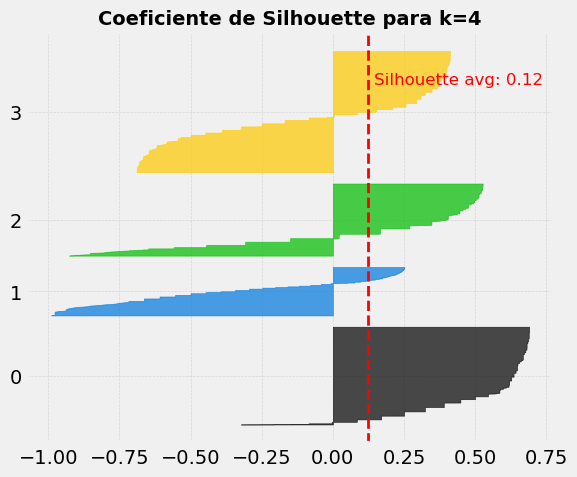

In [137]:
# Gráficos
for k in [2, 3, 4]:
    plt.figure(figsize=(6, 5))  # Ajusta el tamaño de la figura
    
    gmm = gmm_models[k - 2]
    y_pred = gmm.predict(X)
    silhouette_coefficients = silhouette_samples(X, y_pred)
    silhouette_avg = silhouette_score(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.nipy_spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster label", fontsize=12)

    if k in (5, 6):
        plt.gca().set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient", fontsize=12)

    # Agregar línea vertical del silhouette_avg
    plt.axvline(silhouette_avg, color='red', linestyle="--", linewidth=2)
    
    # Agregar texto al lado de la línea
    plt.text(silhouette_avg + 0.02, pos * 0.9, f"Silhouette avg: {silhouette_avg:.2f}",
             color="red", fontsize=12, verticalalignment='center')

    plt.title(f"Coeficiente de Silhouette para k={k}", fontsize=14, fontweight="bold")

    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()  # Muestra cada gráfico individualmente

Muy malos los resultados; sin embargo, de todo lo malo, podemos decir que el mejor es el que maneja k = 3 clusters.

**To do**: Falta explicacion

In [139]:
gmm_elegido = gmm_models[1]
gmm_elegido

GaussianMixture(n_components=3, random_state=42)

In [141]:
# Añadir los labels de los clusters al dataframe
df['cluster'] = gmm_elegido.predict(X)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9624\3814503156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = gmm_elegido.predict(X)


In [142]:
# Ver cantidad de datos por cluster
cluster_counts = df['cluster'].value_counts()
cluster_counts

cluster
0    8666
2    6211
1    2783
Name: count, dtype: int64

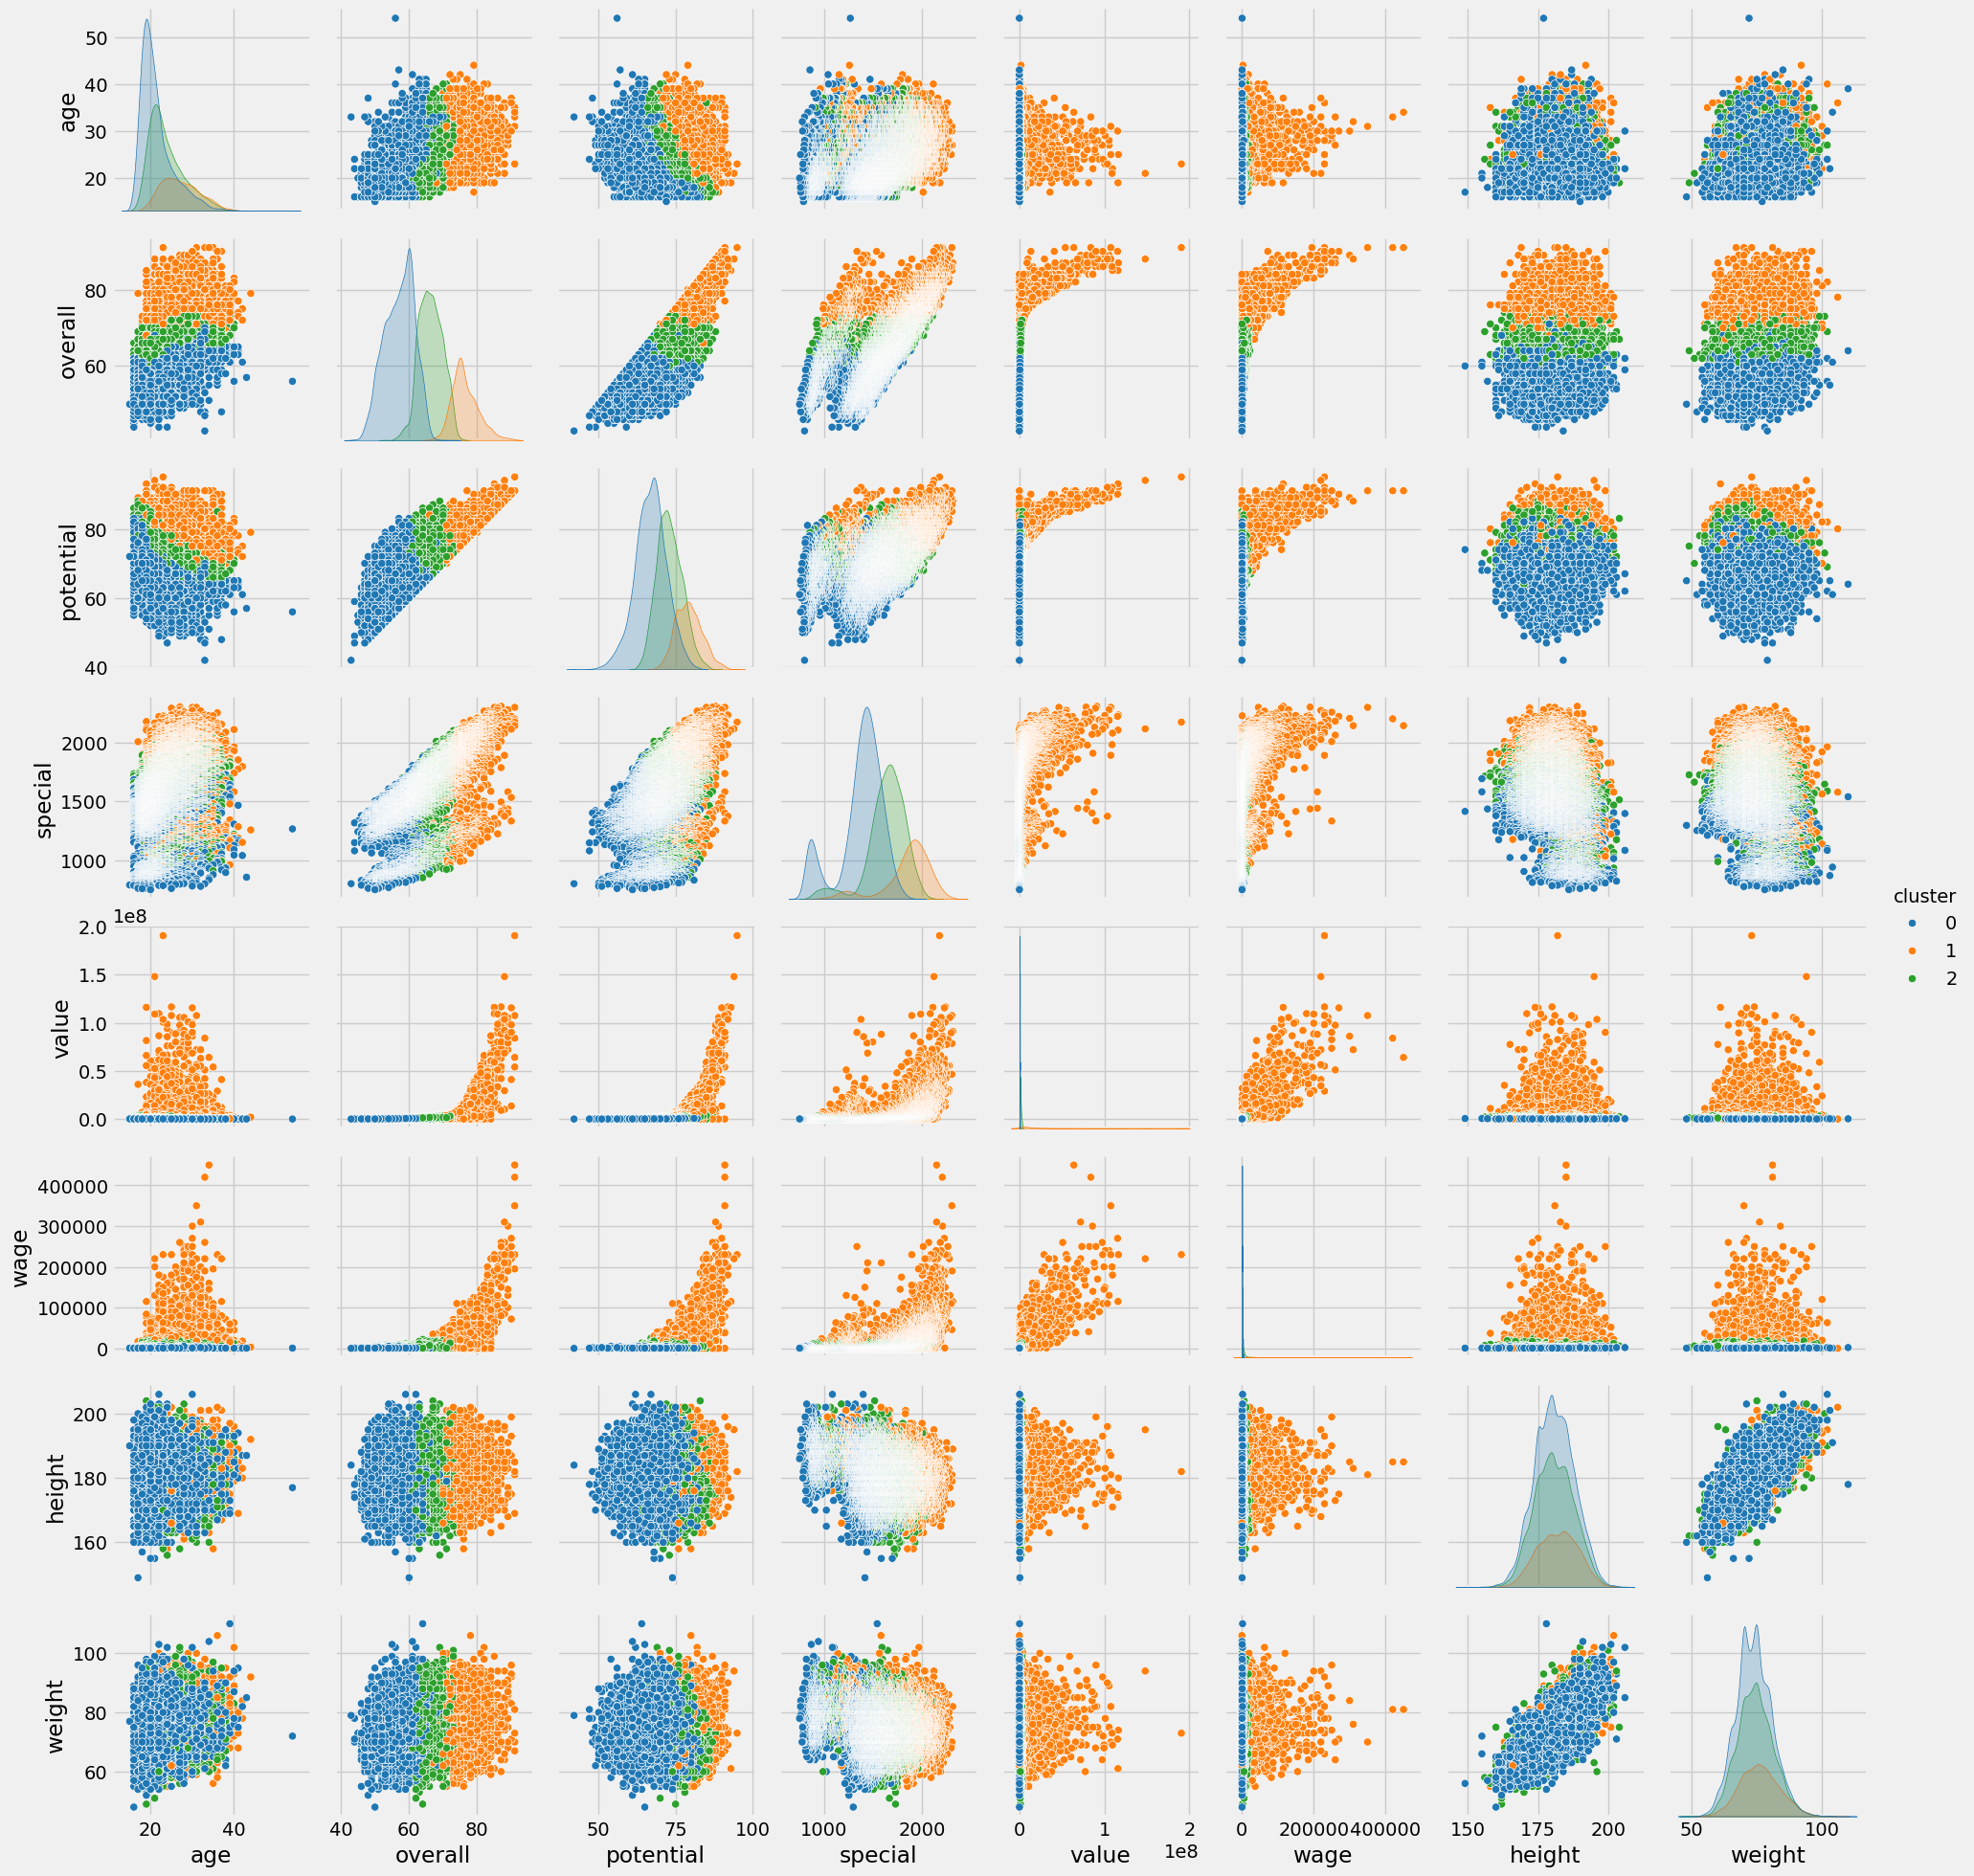

In [143]:
# Crear el pairplot
sns.pairplot(df, hue='cluster', diag_kind='kde', palette='tab10')
plt.show()

### 4. Dataset Aerolineas

#### 4.1. Carga de datos

In [149]:
# Se carga el dataset
xlsx_file = 'EastWestAirlines.xlsx'
df_airlines = pd.read_excel(xlsx_file, sheet_name='data')
df_airlines.columns = df_airlines.columns.str.lower()
df_airlines.head(3)

,id#,balance,qual_miles,cc1_miles,cc2_miles,cc3_miles,bonus_miles,bonus_trans,flight_miles_12mo,flight_trans_12,days_since_enroll,award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


In [150]:
df2 = df_airlines.drop(columns=['qual_miles','id#','cc1_miles', 'cc2_miles', 'cc3_miles', 'award?'])
df2.head(3)


,balance,bonus_miles,bonus_trans,flight_miles_12mo,flight_trans_12,days_since_enroll
0,28143,174,1,0,0,7000
1,19244,215,2,0,0,6968
2,41354,4123,4,0,0,7034


#### 4.2. Metodo Kmeans


In [151]:
X2 = df2.values

In [152]:
kmeans2_k, inertias2, silhouettes2, ks2 = train_kmeans(X2, max_k = 15, seed=SEED)

#### 4.3. Metricas 

In [153]:
df2_summary = pd.DataFrame({'inertia': inertias2, 'silhouette': silhouettes2}, index=ks2)
df2_summary.index.name = 'k'
df2_summary

,inertia,silhouette
k,,
2,2.082125e+13,0.741953
3,1.179123e+13,0.649715
4,7.547378e+12,0.590100
5,5.895337e+12,0.549053
6,4.540129e+12,0.516873
7,4.326515e+12,0.499128
8,3.446803e+12,0.480700
9,3.060268e+12,0.420868
10,2.648607e+12,0.440498


#### Metodo del codo

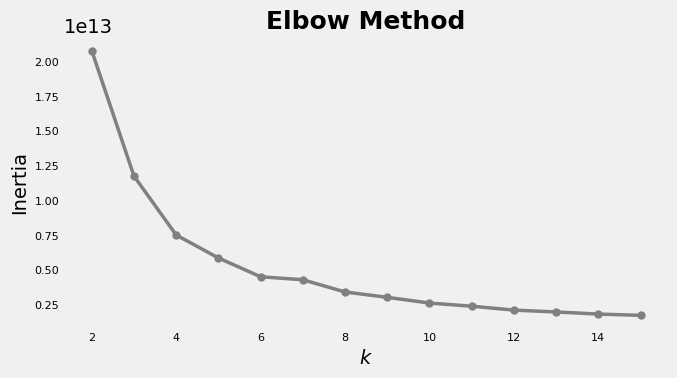

In [155]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks2, inertias2, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Inertia", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Elbow Method", fontsize=18, fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.savefig("elbow.png", dpi=600, transparent=True)
plt.show()

#### Analisis de silueta

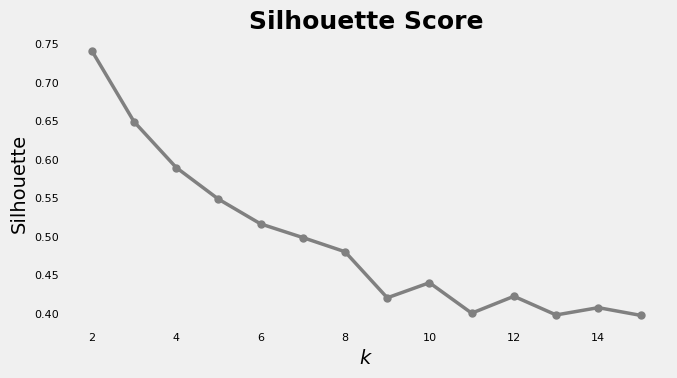

In [156]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks2, silhouettes2, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Silhouette", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Silhouette Score", fontsize=18, fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.savefig("silhouette_score.png", dpi=600, transparent=True)
plt.show()

#### Análisis de siluetas para evaluar la calidad de la agrupación


Para k=2 el promedio del silhouette es: 0.74


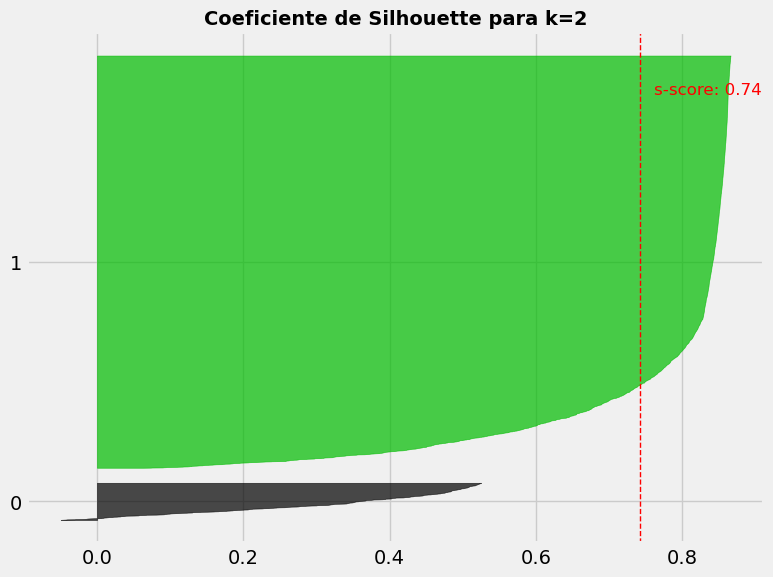

Para k=3 el promedio del silhouette es: 0.65


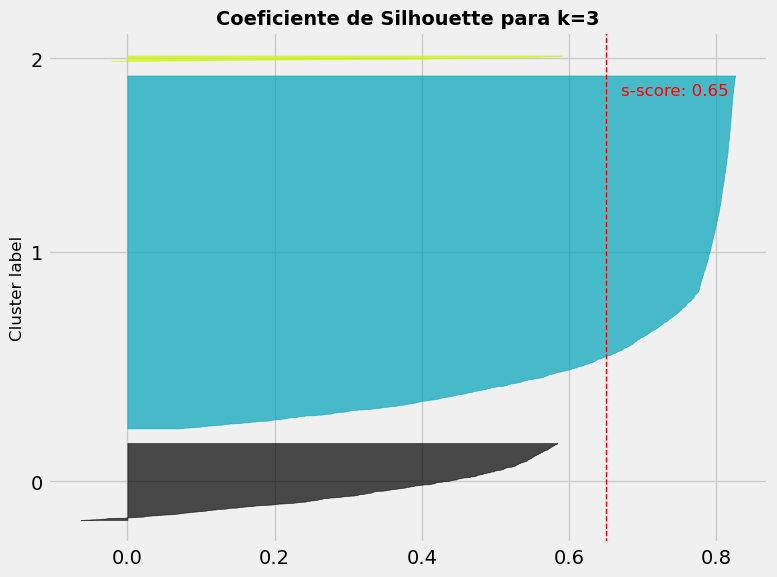

Para k=4 el promedio del silhouette es: 0.59


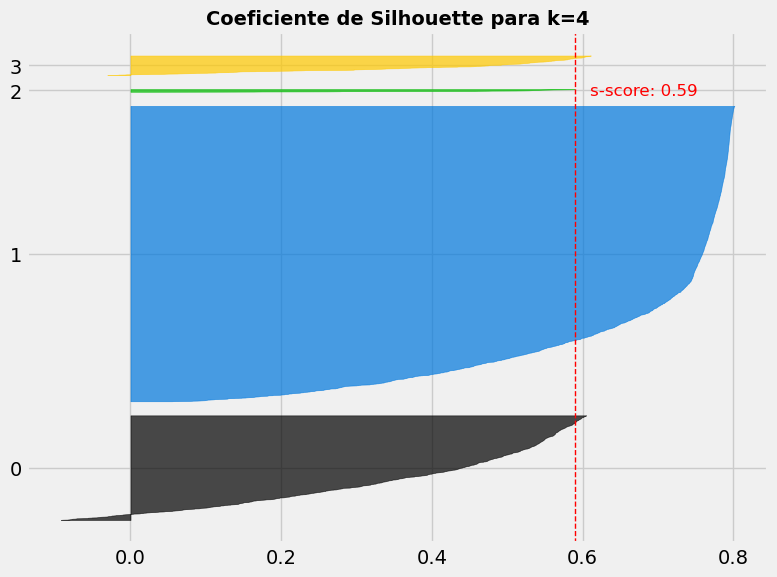

Para k=5 el promedio del silhouette es: 0.55


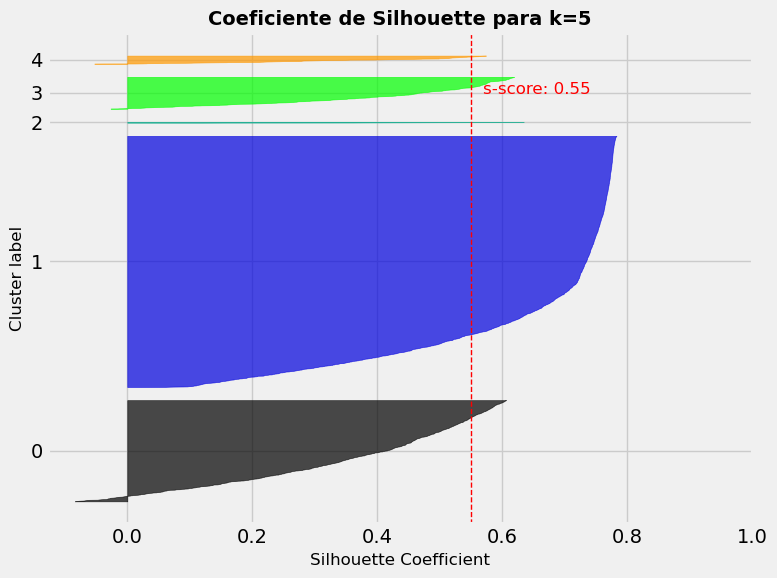

Para k=6 el promedio del silhouette es: 0.52


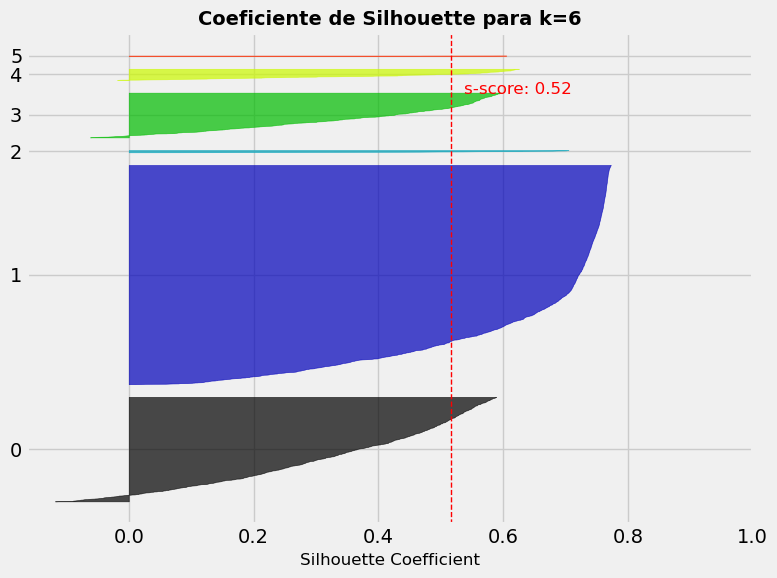

Para k=7 el promedio del silhouette es: 0.50


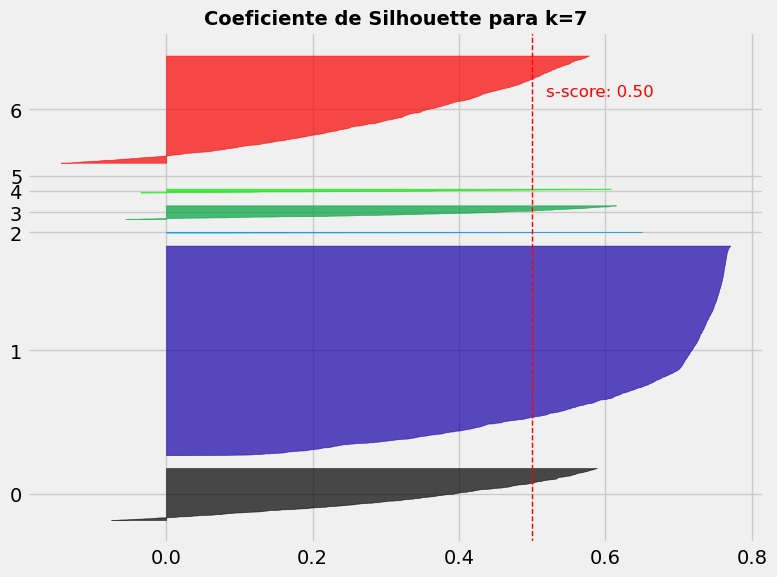

Para k=8 el promedio del silhouette es: 0.48


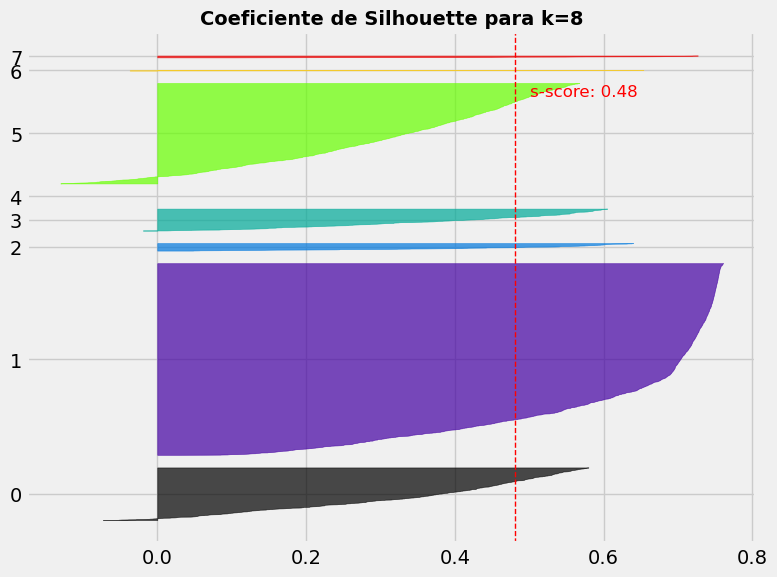

Para k=9 el promedio del silhouette es: 0.42


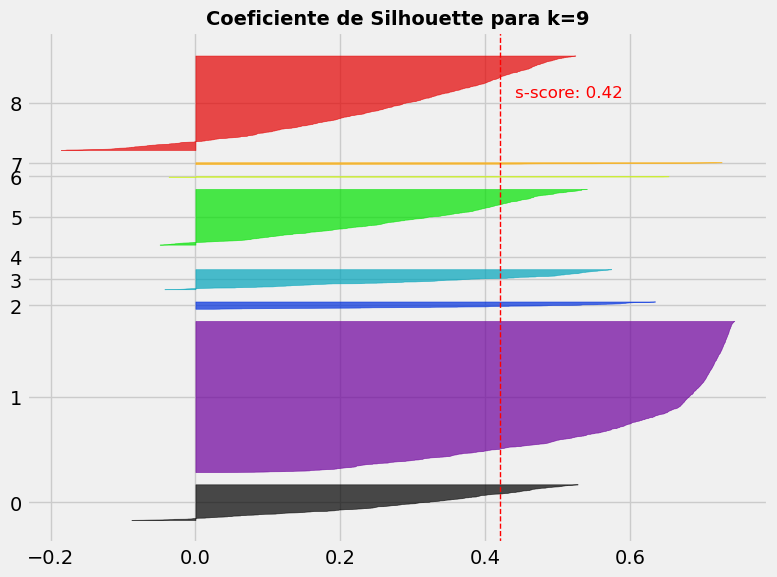

Para k=10 el promedio del silhouette es: 0.44


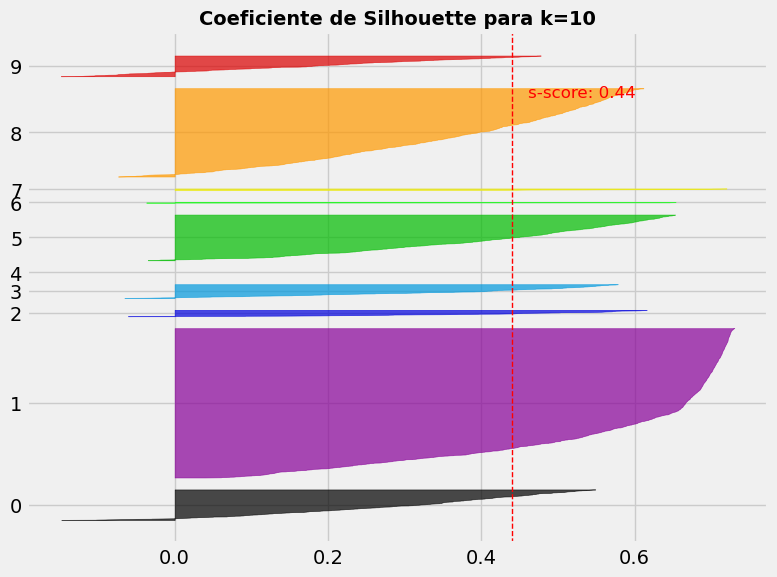

Para k=11 el promedio del silhouette es: 0.40


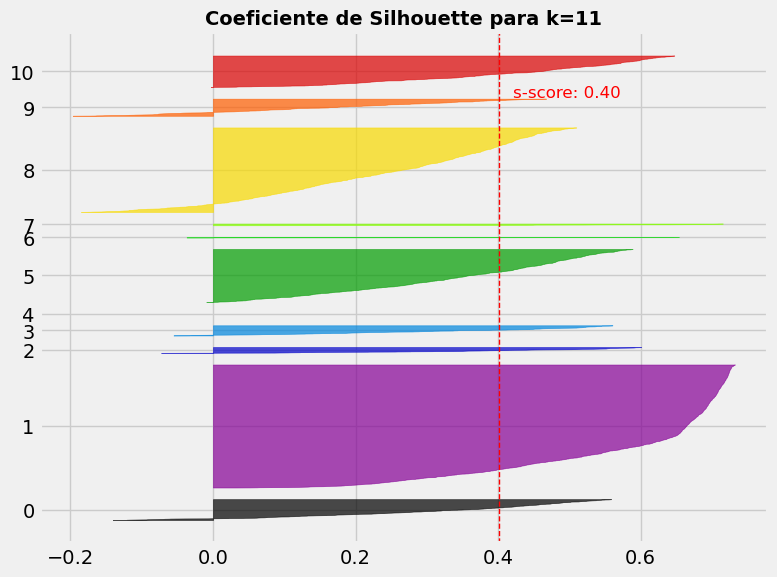

Para k=12 el promedio del silhouette es: 0.42


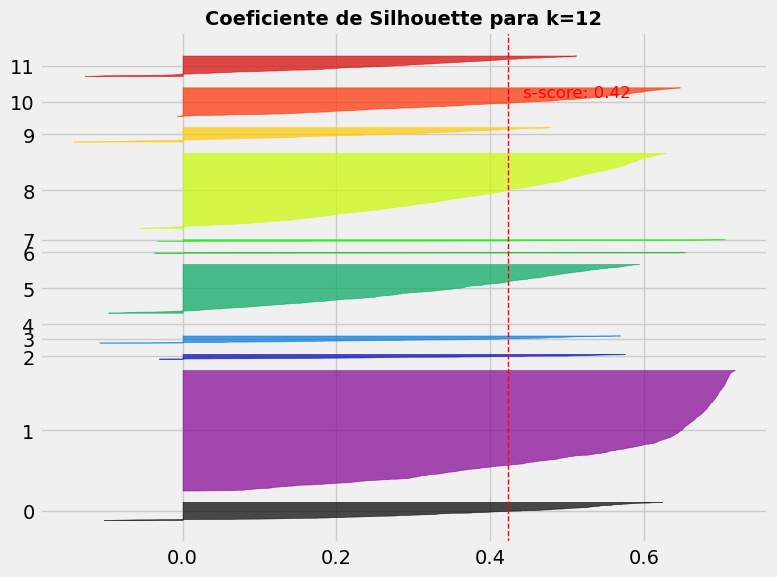

Para k=13 el promedio del silhouette es: 0.40


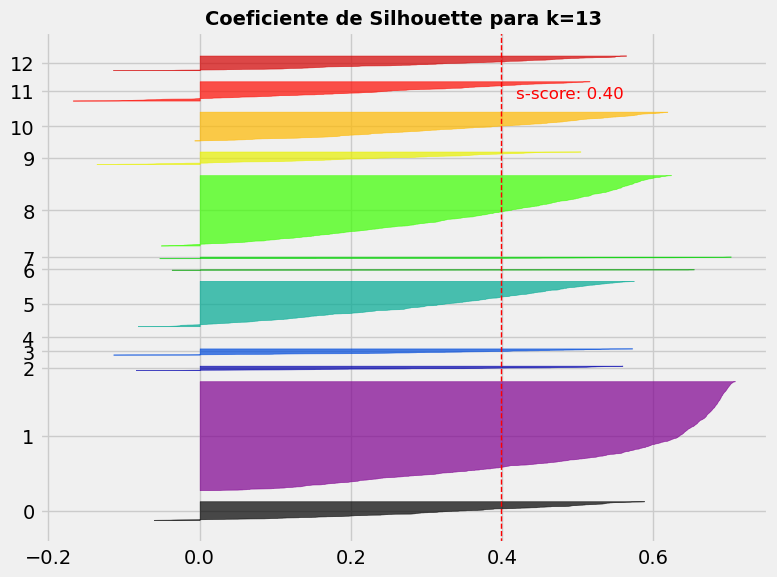

Para k=14 el promedio del silhouette es: 0.41


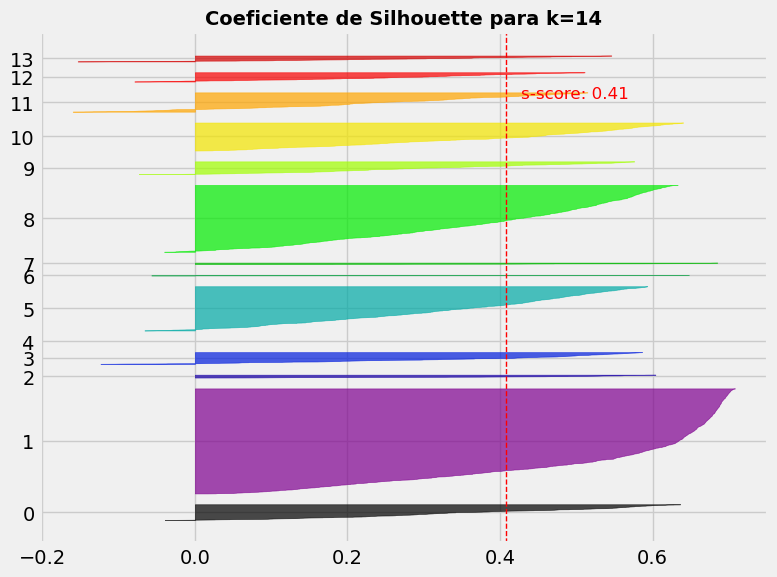

Para k=15 el promedio del silhouette es: 0.40


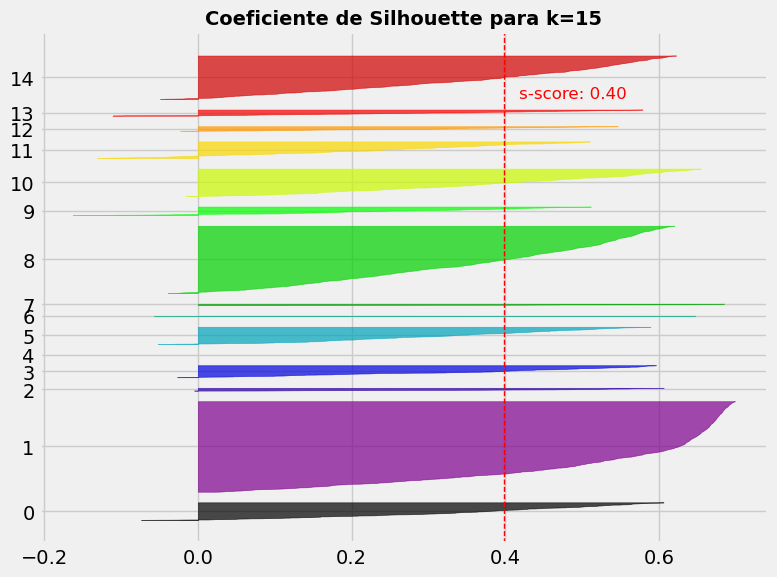

In [160]:
for k in ks2:
    plt.figure(figsize=(8, 6))  # Ajusta el tamaño de la figura
    
    y2_pred = kmeans2_k[k - 2].labels_
    silhouette2_coefficients = silhouette_samples(X2, y2_pred)
    silhouette2_avg = silhouette_score(X2, y2_pred)  # Cálculo del promedio
    print(f"Para k={k} el promedio del silhouette es: {silhouette2_avg:.2f}")

    padding = len(X2) // 30
    pos = padding
    ticks = []
    
    for i in range(k):
        coeffs2 = silhouette2_coefficients[y2_pred == i]
        coeffs2.sort()

        color = mpl.cm.nipy_spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs2)), 0, coeffs2,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs2) // 2)
        pos += len(coeffs2) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster label", fontsize=12)

    if k in (5, 6):
        plt.gca().set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient", fontsize=12)

    # Agregar línea vertical del silhouette_avg
    plt.axvline(silhouette2_avg, color='red', linestyle="--", linewidth=1)
    
    # Agregar texto al lado de la línea
    plt.text(silhouette2_avg + 0.02, pos * 0.9, f"s-score: {silhouette2_avg:.2f}",
             color="red", fontsize=12, verticalalignment='center')

    plt.title(f"Coeficiente de Silhouette para k={k}", fontsize=14, fontweight="bold")

    plt.grid(True)
    plt.tight_layout()
    plt.show()  # Muestra cada gráfico individualmente

Parece que la mejor elección para el caso va a ser para k = 6.

**To Do**: Explicación.

In [162]:
kmeans2_elegido = kmeans2_k[4]
kmeans2_elegido

KMeans(n_clusters=6, random_state=42)

A continuación se muestran los centroides resultantes:

In [163]:
for i in range(kmeans2_elegido.n_clusters):
    print(f"Cluster {i}: \n\t {kmeans2_elegido.cluster_centers_[i].round(3)}\n")

Cluster 0: 
	 [8.4211550e+04 2.5113077e+04 1.4913000e+01 5.8673500e+02 1.7460000e+00
 4.4003990e+03]

Cluster 1: 
	 [2.3488198e+04 7.5400440e+03 8.2890000e+00 2.3683100e+02 7.4400000e-01
 3.7068830e+03]

Cluster 2: 
	 [7.20621217e+05 6.02981740e+04 2.16090000e+01 1.53347800e+03
 5.52200000e+00 6.25973900e+03]

Cluster 3: 
	 [1.78336528e+05 3.52335560e+04 1.74050000e+01 9.03231000e+02
 2.45000000e+00 4.95417700e+03]

Cluster 4: 
	 [3.63319265e+05 4.99647440e+04 2.01110000e+01 1.58948700e+03
 4.73500000e+00 5.66887200e+03]

Cluster 5: 
	 [1.2889158e+06 3.9098000e+04 2.4600000e+01 2.7546000e+03 1.1400000e+01
 7.8216000e+03]



In [164]:
# Añadir los labels de los clusters al dataframe
df2['cluster'] = kmeans2_elegido.labels_

In [165]:
# Ver cantidad de datos por cluster
cluster_counts = df2['cluster'].value_counts()
cluster_counts

cluster
1    2293
0    1093
3     468
4     117
2      23
5       5
Name: count, dtype: int64

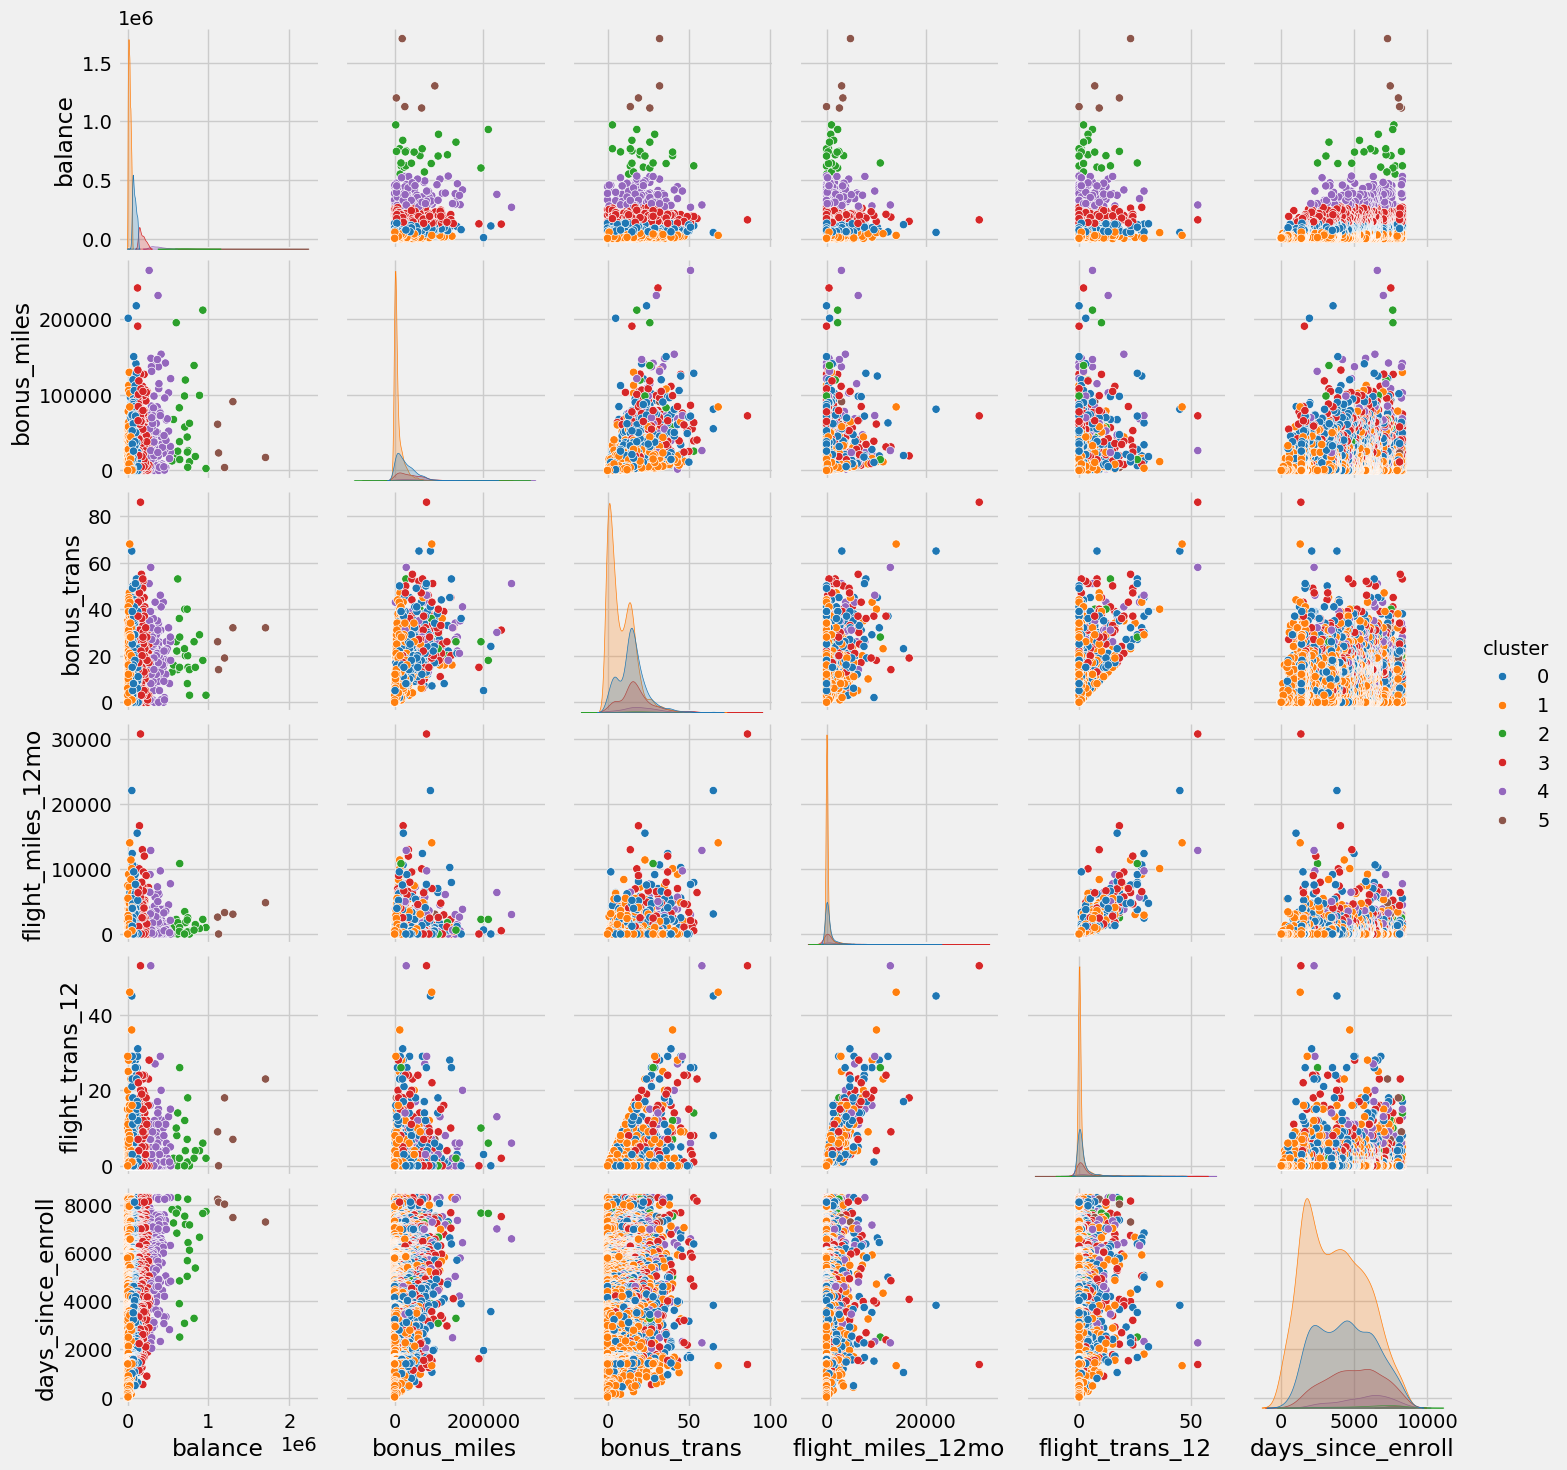

In [166]:
# Crear el pairplot
sns.pairplot(df2, hue='cluster', diag_kind='kde', palette='tab10')
plt.show()

#### 4.4. GMM

In [167]:
try:
    df2.drop('cluster', axis=1, inplace=True)        
except:
    pass
df2.head(3)

,balance,bonus_miles,bonus_trans,flight_miles_12mo,flight_trans_12,days_since_enroll
0,28143,174,1,0,0,7000
1,19244,215,2,0,0,6968
2,41354,4123,4,0,0,7034


Se escalo por que daba peor sin escalar

In [171]:
X2 = df2.values
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2) 

In [172]:
# gmm2_models, bics2, aics2, silhouettes2, ks2 = train_gmm(X2, max_k=15, seed=SEED)
gmm2_models, bics2, aics2, silhouettes2, ks2 = train_gmm(X2_scaled, max_k=15, seed=SEED)

In [173]:
df_gmm2_summary = pd.DataFrame({'BIC': bics2, 'AIC': aics2, 'silhouette': silhouettes2}, index=ks2)
df_gmm2_summary.index.name = 'k'
df_gmm2_summary

,BIC,AIC,silhouette
k,,,
2,-12798.683829,-13144.842808,0.207853
3,-17252.545206,-17774.930573,0.058596
4,-24223.959272,-24922.571028,0.065022
5,-26046.309981,-26921.148127,0.047510
6,-23390.519470,-24441.584005,0.049863
7,-34349.675421,-35576.966345,-0.012244
8,-34400.343210,-35803.860523,-0.019392
9,-37779.851290,-39359.594992,0.005338
10,-37728.120274,-39484.090365,-0.006222


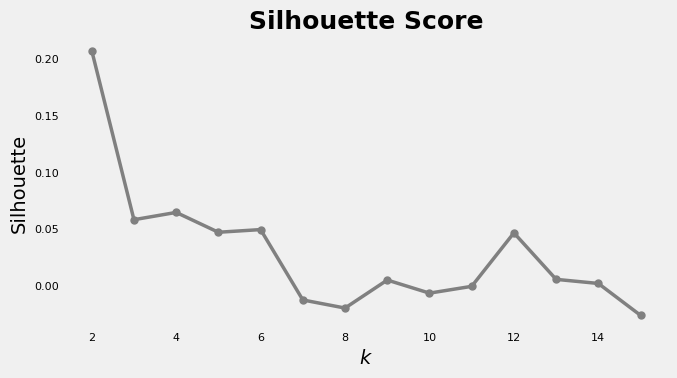

In [174]:
plt.style.use("fivethirtyeight")
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ks2, silhouettes2, "o-", color="grey", linewidth=2.5, markersize=5)

ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel("Silhouette", fontsize=14)
ax.tick_params(axis='both', labelsize=8)

ax.set_title("Silhouette Score", fontsize=18, fontweight="bold")
ax.grid(False)

plt.tight_layout()
plt.savefig("silhouette_score.png", dpi=600, transparent=True)
plt.show()

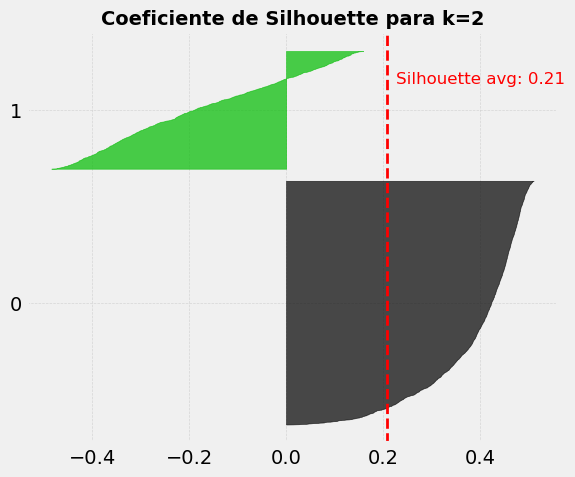

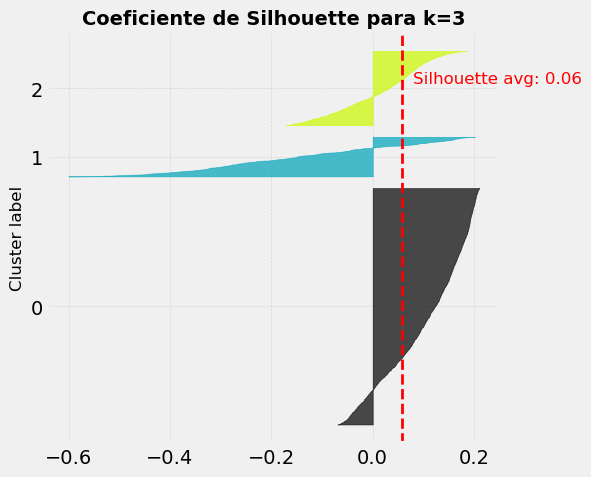

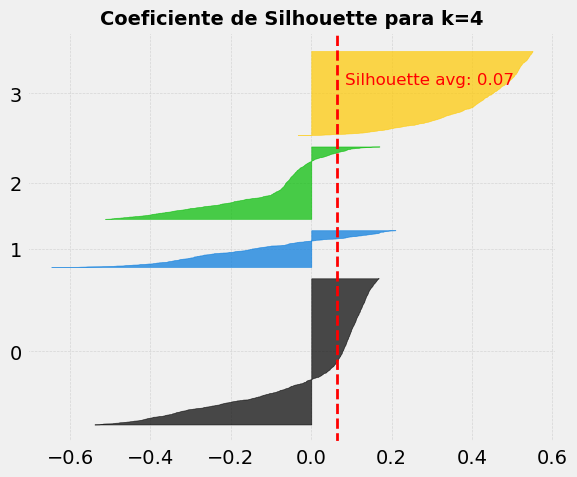

In [176]:
# Gráficos
for k in [2, 3, 4]:
    plt.figure(figsize=(6, 5))  # Ajusta el tamaño de la figura
    
    gmm2 = gmm2_models[k - 2]
    y2_pred = gmm2.predict(X2_scaled)
    silhouette2_coefficients = silhouette_samples(X2_scaled, y2_pred)
    silhouette2_avg = silhouette_score(X2_scaled, y2_pred)

    padding = len(X2_scaled) // 30
    pos = padding
    ticks = []
    
    for i in range(k):
        coeffs2 = silhouette2_coefficients[y2_pred == i]
        coeffs2.sort()

        color = mpl.cm.nipy_spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs2)), 0, coeffs2,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs2) // 2)
        pos += len(coeffs2) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster label", fontsize=12)

    if k in (5, 6):
        plt.gca().set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient", fontsize=12)

    # Agregar línea vertical del silhouette_avg
    plt.axvline(silhouette2_avg, color='red', linestyle="--", linewidth=2)
    
    # Agregar texto al lado de la línea
    plt.text(silhouette2_avg + 0.02, pos * 0.9, f"Silhouette avg: {silhouette2_avg:.2f}",
             color="red", fontsize=12, verticalalignment='center')

    plt.title(f"Coeficiente de Silhouette para k={k}", fontsize=14, fontweight="bold")

    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()  # Muestra cada gráfico individualmente

Muy malos los resultados; sin embargo, de todo lo malo, podemos decir que el mejor es el que maneja k = 3 clusters.

**To do**: Falta explicacion

In [177]:
gmm2_elegido = gmm2_models[0]
gmm2_elegido

GaussianMixture(n_components=2, random_state=42)

In [178]:
# Añadir los labels de los clusters al dataframe
df2['cluster'] = gmm2_elegido.predict(X2_scaled)

In [179]:
# Ver cantidad de datos por cluster
cluster_counts = df2['cluster'].value_counts()
cluster_counts

cluster
0    2696
1    1303
Name: count, dtype: int64

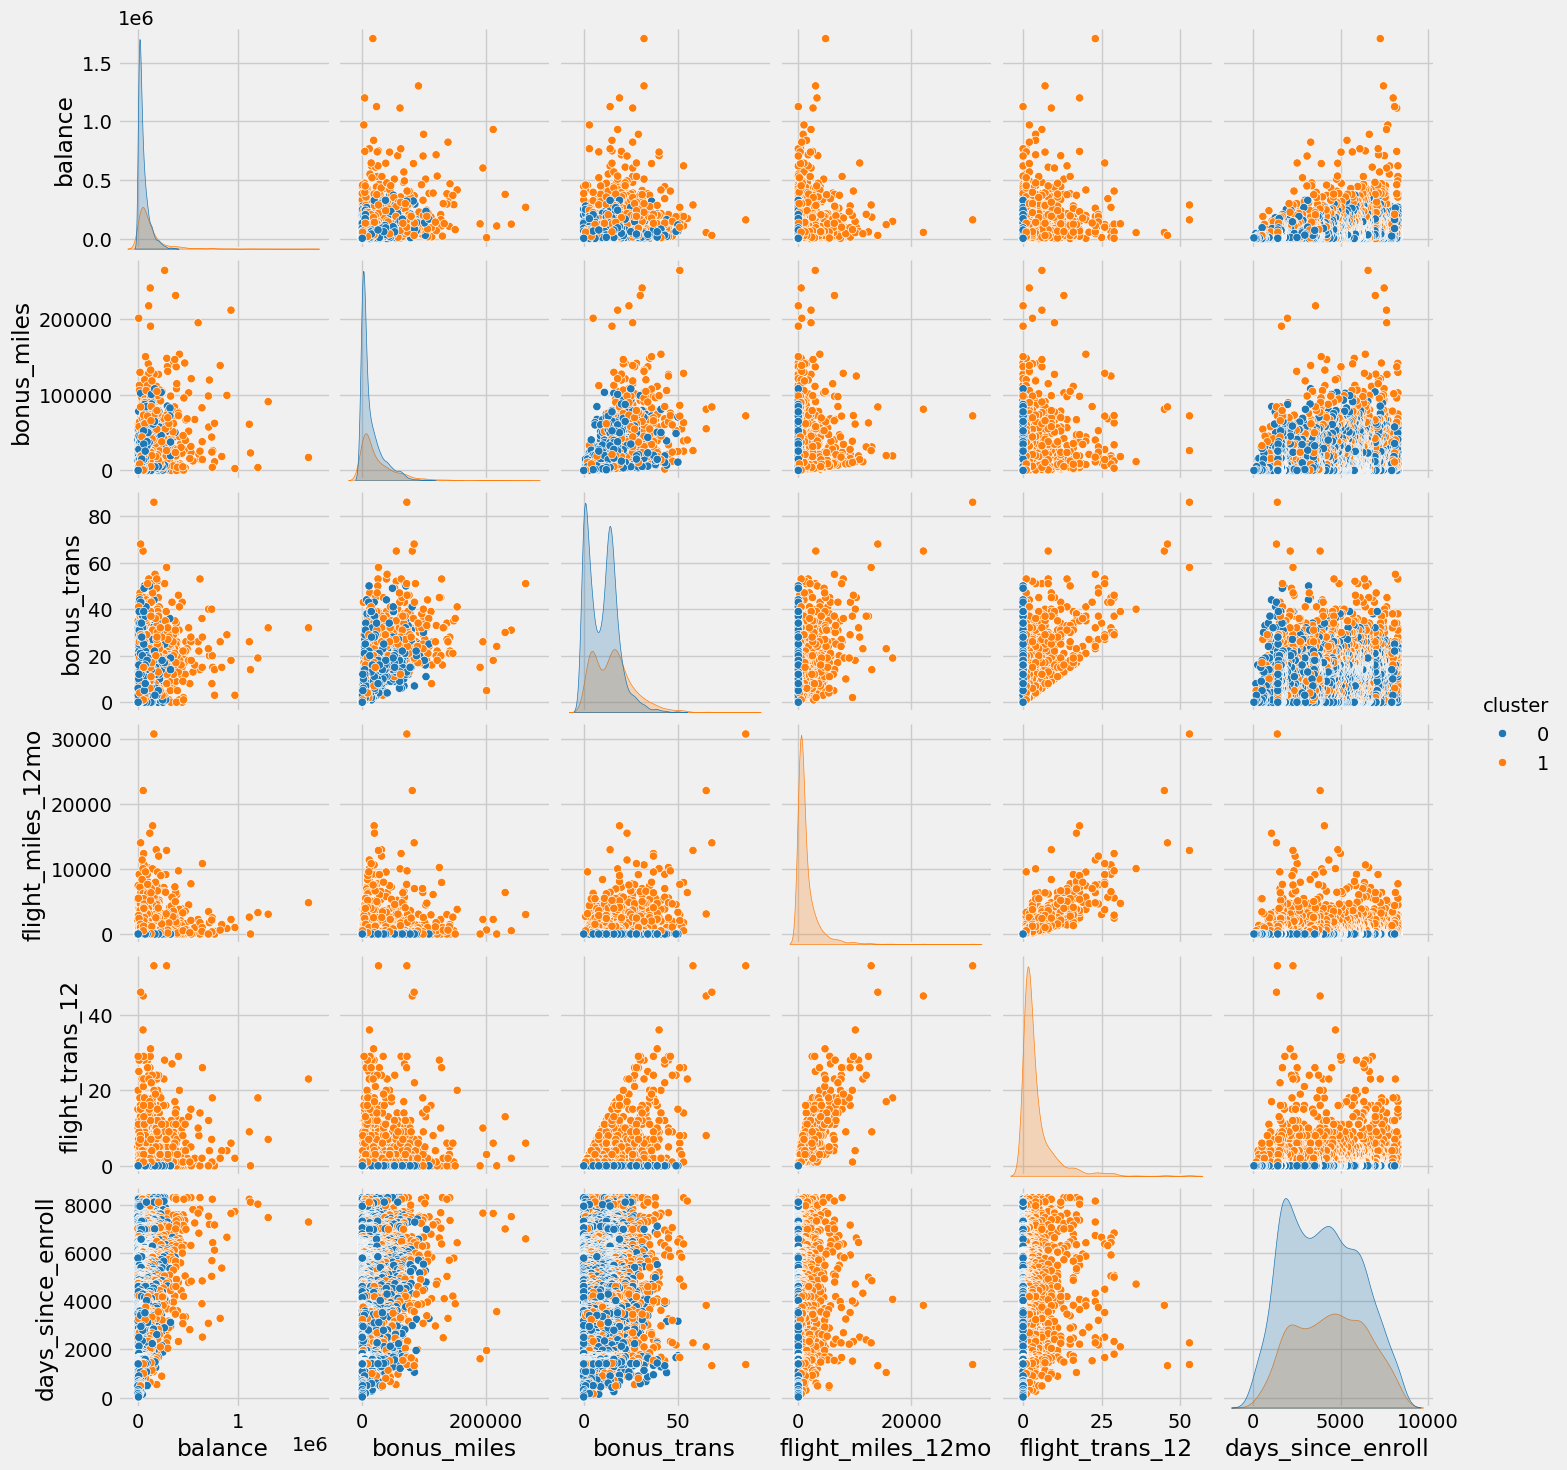

In [180]:
# Crear el pairplot
sns.pairplot(df2, hue='cluster', diag_kind='kde', palette='tab10')
plt.show()